# VWAP Mean Reversion in Futures Markets
## Signal Research, Risk Analysis & Execution Testing

**Instruments**: ZN 10-Year Treasury Note Futures · 6E Euro FX Futures  
**Data**: Databento GLBX.MDP3 · Front-month filtered · Jan 2023–May 2026 (ZN) · Jul 2021–Jun 2026 (6E)

---

### Overview

This notebook investigates intraday VWAP mean reversion as a systematic trading signal in two futures markets: ZN (10-Year Treasury Note futures) and 6E (Euro FX futures). The project follows the strategy from raw tick data through signal diagnostics, historical backtesting, risk analysis, and live implementation considerations.

The research pipeline includes:

1. Data quality validation and front-month contract filtering
2. VWAP signal construction using one-minute trade data
3. AR(1) / OU-style mean-reversion diagnostics
4. Four-hour event-based reversion analysis
5. Interleaved in-sample / out-of-sample holdout testing
6. Regime-filter and parameter comparison
7. Student's-t Monte Carlo stress testing under prop-account constraints
8. Empirical Kelly sizing as a theoretical risk benchmark
9. Contract-size optimization using Monte Carlo and historical path replay
10. Cross-market validation on 6E Euro FX
11. Standalone strategy performance and equity-curve comparison

**Key finding**: ZN exhibits measurable intraday mean-reversion behavior around daily VWAP. The fitted intraday AR(1) process has a half-life of approximately **19.2 minutes** (R² = 0.932), while **80.7%** of fresh 2.5σ deviations reach the 1.0σ reversion threshold within four hours before a 4.0σ continuation threshold.

Profitability is sensitive to parameter selection, regime filtering, position sizing, and instrument economics. On ZN, the tested filtered configurations remain profitable after transaction costs, while the same framework applied to 6E produces negative expectancy. The project therefore treats **statistical mean reversion** and **executable trading edge** as related but distinct questions.

In [22]:
import os, glob, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats as scipy_stats
from statsmodels.regression.linear_model import OLS
from statsmodels.tools import add_constant
from fredapi import Fred
import databento as db
import warnings
warnings.filterwarnings("ignore")

plt.style.use("dark_background")
plt.rcParams.update({"figure.facecolor": "#0d0d1a", "axes.facecolor": "#0d0d1a",
                     "axes.edgecolor": "#444", "grid.color": "#222",
                     "text.color": "white", "axes.labelcolor": "white",
                     "xtick.color": "white", "ytick.color": "white"})

# ── ZN SPECS ──────────────────────────────────────────────────────────────────
ZN_TICK_SIZE    = 1/64
ZN_TICK_VALUE   = 15.625
ZN_COMMISSION   = 4.10       # $ per contract RT

# ── 6E SPECS ──────────────────────────────────────────────────────────────────
E6_TICK_SIZE    = 0.00005
E6_TICK_VALUE   = 6.25
E6_COMMISSION   = 4.72       # $ per contract RT

# ── APEX 150K EOD TRAIL RULES ─────────────────────────────────────────────────
APEX = {
    "eval_fee":            149,
    "eval_profit_target":  9000,
    "eval_max_drawdown":   4000,
    "eval_daily_loss":     2000,
    "funded_max_drawdown": 4000,
    "funded_daily_loss":   2000,
    "funded_cushion":      4100,
    "funded_payout_split": 0.80,
    "max_accounts":        20,
    "eval_contracts":      10,
    "funded_contracts":    10,
}

# Optional: set FRED_API_KEY in your environment to retrieve macro data.
# Full execution also requires the proprietary Databento datasets used in this analysis.
FRED_API_KEY = os.getenv("FRED_API_KEY", "")
print("Constants defined.")
print(f"ZN: ${ZN_TICK_VALUE}/tick | 6E: ${E6_TICK_VALUE}/tick")
print(f"Commission ratio ZN/6E: {ZN_TICK_VALUE/E6_TICK_VALUE:.1f}x more favorable per tick on ZN")

Constants defined.
ZN: $15.625/tick | 6E: $6.25/tick
Commission ratio ZN/6E: 2.5x more favorable per tick on ZN


## 2. Data Pipeline & Quality Validation

### The Parent Symbology Problem

Databento's `stype_in="parent"` returns **all instruments** under a root symbol — 
outrights, calendar spreads, and inter-commodity spreads. Calendar spread prices 
for ZN (e.g. ZNH3-ZNM3 ≈ -0.63) and 6E (e.g. 6EM3-6EH3 ≈ 0.003) are 
economically valid but catastrophically wrong when mixed into outright OHLCV bars.

**Effect**: A single spread trade in a 1-minute window sets that bar's low to -0.63 
(for ZN trading at ~115) or 0.003 (for 6E trading at ~1.08), creating artificial 
wicks of hundreds of ticks. These inflate VWAP std and produce spurious entry signals.

**Discovered via**: Cross-validation against Rithmic historical bars (independent 
source, server-side aggregation). Rithmic showed 2-tick median bar ranges; 
Databento parent symbology showed 10-tick mean ranges.

**Fix**: Filter each daily file to the front-month contract symbol only, using a 
quarterly roll calendar based on volume leadership.

In [23]:
# ── ZN ROLL CALENDAR ──────────────────────────────────────────────────────────
ZN_ROLL = {
    ("2023-01-01","2023-03-17"): "ZNH3", ("2023-03-17","2023-06-16"): "ZNM3",
    ("2023-06-16","2023-09-15"): "ZNU3", ("2023-09-15","2023-12-15"): "ZNZ3",
    ("2023-12-15","2024-03-15"): "ZNH4", ("2024-03-15","2024-06-14"): "ZNM4",
    ("2024-06-14","2024-09-13"): "ZNU4", ("2024-09-13","2024-12-13"): "ZNZ4",
    ("2024-12-13","2025-03-14"): "ZNH5", ("2025-03-14","2025-06-13"): "ZNM5",
    ("2025-06-13","2025-09-12"): "ZNU5", ("2025-09-12","2025-12-12"): "ZNZ5",
    ("2025-12-12","2026-03-13"): "ZNH6", ("2026-03-13","2026-06-13"): "ZNM6",
    ("2026-06-13","2027-01-01"): "ZNU6",
}

# ── 6E ROLL CALENDAR ──────────────────────────────────────────────────────────
E6_ROLL = {
    ("2021-07-01","2021-09-10"): "6EU1", ("2021-09-10","2021-12-10"): "6EZ1",
    ("2021-12-10","2022-03-11"): "6EH2", ("2022-03-11","2022-06-10"): "6EM2",
    ("2022-06-10","2022-09-09"): "6EU2", ("2022-09-09","2022-12-09"): "6EZ2",
    ("2022-12-09","2023-03-10"): "6EH3", ("2023-03-10","2023-06-09"): "6EM3",
    ("2023-06-09","2023-09-08"): "6EU3", ("2023-09-08","2023-12-08"): "6EZ3",
    ("2023-12-08","2024-03-08"): "6EH4", ("2024-03-08","2024-06-07"): "6EM4",
    ("2024-06-07","2024-09-06"): "6EU4", ("2024-09-06","2024-12-06"): "6EZ4",
    ("2024-12-06","2025-03-07"): "6EH5", ("2025-03-07","2025-06-06"): "6EM5",
    ("2025-06-06","2025-09-05"): "6EU5", ("2025-09-05","2025-12-05"): "6EZ5",
    ("2025-12-05","2026-03-06"): "6EH6", ("2026-03-06","2026-06-05"): "6EM6",
    ("2026-06-05","2026-12-31"): "6EU6",
}

def build_date_lookup(roll_dict):
    lookup = {}
    for (s, e), sym in roll_dict.items():
        cur = pd.Timestamp(s).date()
        end = pd.Timestamp(e).date()
        while cur < end:
            lookup[cur] = sym
            cur += pd.Timedelta(days=1)
    return lookup

ZN_DATE_MAP = build_date_lookup(ZN_ROLL)
E6_DATE_MAP = build_date_lookup(E6_ROLL)
print(f"ZN roll calendar: {len(ZN_DATE_MAP)} dates, "
      f"{len(set(ZN_DATE_MAP.values()))} contracts")
print(f"6E roll calendar: {len(E6_DATE_MAP)} dates, "
      f"{len(set(E6_DATE_MAP.values()))} contracts")

ZN roll calendar: 1461 dates, 15 contracts
6E roll calendar: 2009 dates, 21 contracts


In [24]:
# ── CLEAN FRONT-MONTH DATA: 1-MINUTE OHLCV ────────────────────────────────────

def aggregate_clean(
    data_dirs,
    date_map,
    price_lo,
    price_hi,
    parquet_path,
    instrument=""
):
    """
    Load raw Databento trade files, retain the designated front-month
    outright contract, and aggregate trades into one-minute OHLCV bars.

    If parquet_path already exists, load the cached clean bars.
    """
    if os.path.exists(parquet_path):
        df = pd.read_parquet(parquet_path)
        df.index = pd.to_datetime(df.index, utc=True)

        print(
            f"{instrument}: loaded {len(df):,} one-minute bars "
            f"from {parquet_path}"
        )
        return df

    all_files = []

    for directory in data_dirs:
        all_files.extend(
            sorted(
                glob.glob(
                    os.path.join(
                        directory,
                        "glbx-mdp3-*.trades.dbn.zst"
                    )
                )
            )
        )

    all_files = sorted(set(all_files))

    print(
        f"{instrument}: processing {len(all_files)} raw files..."
    )

    chunks = []
    skipped = 0
    start_time = time.time()

    for i, filepath in enumerate(all_files):
        date_str = (
            os.path.basename(filepath)
            .replace("glbx-mdp3-", "")
            .replace(".trades.dbn.zst", "")
        )

        file_date = pd.Timestamp(date_str).date()
        front_month = date_map.get(file_date)

        if front_month is None:
            skipped += 1
            continue

        try:
            store = db.read_dbn(filepath)
            raw = store.to_df()

            raw = raw[
                (raw["action"] == "T")
                & (raw["symbol"] == front_month)
            ]

            if raw.empty:
                skipped += 1
                continue

            chunks.append(
                raw[["price", "size"]].copy()
            )

        except Exception as exc:
            skipped += 1
            print(
                f"Warning: skipped {os.path.basename(filepath)}: {exc}"
            )

        if i % 200 == 0:
            tick_count = sum(
                len(chunk)
                for chunk in chunks
            )

            print(
                f"  {i + 1}/{len(all_files)} | "
                f"{tick_count:,} ticks | "
                f"{time.time() - start_time:.0f}s"
            )

    if not chunks:
        raise ValueError(
            f"{instrument}: no valid front-month data was loaded."
        )

    df_all = pd.concat(chunks)
    df_all.index = pd.to_datetime(
        df_all.index,
        utc=True
    )
    df_all = df_all.sort_index()

    bad_tick_rate = (
        (df_all["price"] < price_lo)
        | (df_all["price"] > price_hi)
    ).mean()

    print(
        f"  Bad ticks after front-month filtering: "
        f"{bad_tick_rate:.4%}"
    )

    df_1min = (
        df_all["price"]
        .resample("1min")
        .ohlc()
    )

    df_1min["volume"] = (
        df_all["size"]
        .resample("1min")
        .sum()
    )

    df_1min = df_1min.dropna(
        subset=["open", "high", "low", "close"]
    )

    df_1min = df_1min[
        df_1min["volume"] > 0
    ]

    # Remove the bar beginning at the maintenance break.
    df_1min = df_1min[
        ~(
            (df_1min.index.hour == 22)
            & (df_1min.index.minute == 0)
        )
    ]

    df_1min.to_parquet(parquet_path)

    print(
        f"  Saved {len(df_1min):,} one-minute bars "
        f"to {parquet_path}"
    )
    print(f"  Skipped files: {skipped}")

    return df_1min


# ── LOAD OR BUILD ONE-MINUTE PARQUETS ─────────────────────────────────────────

ZN_DIRS = [
    r"path\to\your\ZN_data_directory_1",
    r"path\to\your\ZN_data_directory_2",
]

E6_DIRS = [
     r"path\to\your\6E_data_directory"
]

df_zn_raw = aggregate_clean(
    ZN_DIRS,
    ZN_DATE_MAP,
    90,
    135,
    "zn_1min_clean.parquet",
    "ZN"
)

df_e6_raw = aggregate_clean(
    E6_DIRS,
    E6_DATE_MAP,
    0.90,
    1.35,
    "6e_1min_clean.parquet",
    "6E"
)

ZN: loaded 971,062 one-minute bars from zn_1min_clean.parquet
6E: loaded 1,730,682 one-minute bars from 6e_1min_clean.parquet


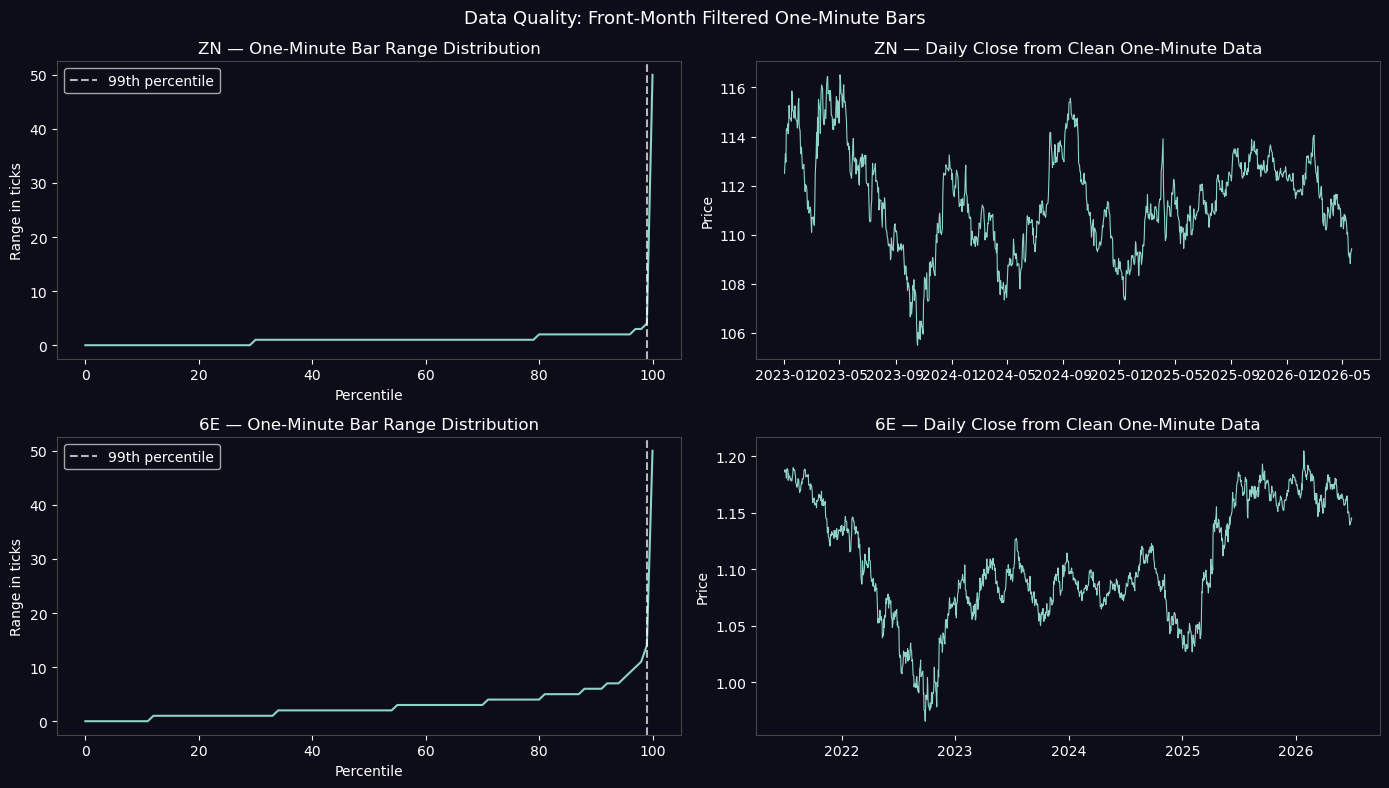

Data Quality Summary:
Metric                                       ZN             6E
--------------------------------------------------------------
Total one-minute bars                   971,062      1,730,682
Date range start                     2023-01-02     2021-07-01
Date range end                       2026-05-22     2026-06-30
Median bar range                      1.0 ticks      2.0 ticks
Bars above 20 ticks                       0.01%          0.31%
Bars above 50 ticks                       0.00%          0.02%


In [25]:
# ── DATA QUALITY VALIDATION: ONE-MINUTE BARS ──────────────────────────────────

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

fig.suptitle(
    "Data Quality: Front-Month Filtered One-Minute Bars",
    fontsize=13
)

for idx, (df_raw, name, tick) in enumerate([
    (df_zn_raw, "ZN", ZN_TICK_SIZE),
    (df_e6_raw, "6E", E6_TICK_SIZE),
]):
    range_ticks = (
        (df_raw["high"] - df_raw["low"])
        / tick
    )

    # Bar-range distribution
    ax = axes[idx, 0]

    percentiles = np.percentile(
        range_ticks.clip(lower=0, upper=50),
        range(101)
    )

    ax.plot(
        range(101),
        percentiles
    )

    ax.axvline(
        99,
        linestyle="--",
        alpha=0.7,
        label="99th percentile"
    )

    ax.set_title(
        f"{name} — One-Minute Bar Range Distribution"
    )
    ax.set_xlabel("Percentile")
    ax.set_ylabel("Range in ticks")
    ax.legend()

    # Daily close series
    ax2 = axes[idx, 1]

    daily_close = (
        df_raw["close"]
        .resample("1D")
        .last()
        .dropna()
    )

    ax2.plot(
        daily_close.index,
        daily_close.values,
        linewidth=0.8
    )

    ax2.set_title(
        f"{name} — Daily Close from Clean One-Minute Data"
    )
    ax2.set_ylabel("Price")

plt.tight_layout()
plt.savefig(
    "data_quality.png",
    dpi=120,
    bbox_inches="tight"
)
plt.show()


print("Data Quality Summary:")
print(f"{'Metric':<32} {'ZN':>14} {'6E':>14}")
print("-" * 62)

summary_rows = [
    (
        "Total one-minute bars",
        f"{len(df_zn_raw):,}",
        f"{len(df_e6_raw):,}"
    ),
    (
        "Date range start",
        str(df_zn_raw.index[0].date()),
        str(df_e6_raw.index[0].date())
    ),
    (
        "Date range end",
        str(df_zn_raw.index[-1].date()),
        str(df_e6_raw.index[-1].date())
    ),
    (
        "Median bar range",
        (
            f"{((df_zn_raw['high'] - df_zn_raw['low'])
                 / ZN_TICK_SIZE).median():.1f} ticks"
        ),
        (
            f"{((df_e6_raw['high'] - df_e6_raw['low'])
                 / E6_TICK_SIZE).median():.1f} ticks"
        )
    ),
    (
        "Bars above 20 ticks",
        (
            f"{(((df_zn_raw['high'] - df_zn_raw['low'])
                  / ZN_TICK_SIZE) > 20).mean():.2%}"
        ),
        (
            f"{(((df_e6_raw['high'] - df_e6_raw['low'])
                  / E6_TICK_SIZE) > 20).mean():.2%}"
        )
    ),
    (
        "Bars above 50 ticks",
        (
            f"{(((df_zn_raw['high'] - df_zn_raw['low'])
                  / ZN_TICK_SIZE) > 50).mean():.2%}"
        ),
        (
            f"{(((df_e6_raw['high'] - df_e6_raw['low'])
                  / E6_TICK_SIZE) > 50).mean():.2%}"
        )
    ),
]

for metric, zn_value, e6_value in summary_rows:
    print(
        f"{metric:<32} "
        f"{zn_value:>14} "
        f"{e6_value:>14}"
    )

## 3. VWAP Signal Construction

Daily-anchored VWAP resets at midnight UTC. Typical price is defined from each one-minute bar, and VWAP is calculated cumulatively using observed trade volume:

$$P_t^{typ} = \frac{H_t + L_t + C_t}{3}$$

$$\text{VWAP}_t = \frac{\sum_{i=1}^{t} P_i^{typ} \cdot V_i}{\sum_{i=1}^{t} V_i}$$

Signal dispersion is measured using the conventional **expanding sample standard deviation** of typical price within each VWAP day:

$$s_t = \sqrt{\frac{1}{t-1} \sum_{i=1}^{t} \left(P_i^{typ} - \bar{P}_t^{typ}\right)^2}$$

The trading signal is then:

$$z_t = \frac{P_t^{close} - \text{VWAP}_t}{s_t}$$

Unlike a rolling window, the expanding calculation incorporates all observations since the midnight-UTC VWAP reset. A **one-hour warm-up period** is required before entries are permitted.

In [26]:
# ── VWAP FEATURES: ONE-MINUTE BARS ─────────────────────────────────────────────

def build_vwap_features(df_raw, tick_size, name=""):
    """
    Build midnight-UTC anchored VWAP, conventional expanding standard
    deviation, z-score, session labels, and volume features.
    """
    df = df_raw.copy().sort_index()

    # Basic validation
    required = {"open", "high", "low", "close", "volume"}
    missing = required - set(df.columns)

    if missing:
        raise ValueError(
            f"{name}: missing required columns: {sorted(missing)}"
        )

    df["typical_price"] = (
        df["high"]
        + df["low"]
        + df["close"]
    ) / 3.0

    # Midnight UTC VWAP anchor
    df["date"] = df.index.normalize()

    # -------------------------------------------------------------------------
    # VWAP
    # -------------------------------------------------------------------------
    # Avoid groupby.apply() because it can create index-alignment problems.
    df["tp_volume"] = (
        df["typical_price"]
        * df["volume"]
    )

    df["cum_tp_vol"] = (
        df["tp_volume"]
        .groupby(df["date"])
        .cumsum()
    )

    df["cum_vol"] = (
        df["volume"]
        .groupby(df["date"])
        .cumsum()
    )

    # Prevent division by zero
    df["vwap"] = np.where(
        df["cum_vol"] > 0,
        df["cum_tp_vol"] / df["cum_vol"],
        np.nan
    )

    # -------------------------------------------------------------------------
    # CONVENTIONAL EXPANDING STANDARD DEVIATION
    # -------------------------------------------------------------------------
    df["std"] = (
        df["typical_price"]
        .groupby(df["date"])
        .expanding(min_periods=2)
        .std()
        .reset_index(level=0, drop=True)
    )

    df["zscore"] = (
        (df["close"] - df["vwap"])
        / df["std"]
    ).clip(-10, 10)

    # -------------------------------------------------------------------------
    # SESSION LABELS
    # -------------------------------------------------------------------------
    def get_session(hour):
        if 0 <= hour < 7:
            return "Asian"
        if 7 <= hour < 13:
            return "London"
        if 13 <= hour < 21:
            return "New York"
        return "Pre-Asian"

    df["session"] = df.index.hour.map(get_session)

    df["bars_into_day"] = (
        df.groupby("date")
        .cumcount()
    )

    # Twenty one-minute bars = trailing twenty minutes
    df["vol_ma20"] = (
        df["volume"]
        .rolling(20, min_periods=10)
        .mean()
    )

    df["vol_ratio"] = (
        df["volume"]
        / df["vol_ma20"]
    )

    # Cap implausible bar wicks
    max_wick = 20 * tick_size

    df["clean_low"] = np.maximum(
        df["low"],
        df["close"] - max_wick
    )

    df["clean_high"] = np.minimum(
        df["high"],
        df["close"] + max_wick
    )

    # -------------------------------------------------------------------------
    # DIAGNOSTICS BEFORE DROPPING INVALID ROWS
    # -------------------------------------------------------------------------
    if name:
        print(f"\n{name} pre-clean diagnostics:")
        print(f"  Raw bars:              {len(df):,}")
        print(f"  Positive-volume bars:  {(df['volume'] > 0).sum():,}")
        print(f"  VWAP non-null:         {df['vwap'].notna().sum():,}")
        print(f"  Std non-null:          {df['std'].notna().sum():,}")
        print(f"  Z-score non-null:      {df['zscore'].notna().sum():,}")
        print(f"  Zero cumulative vol:   {(df['cum_vol'] <= 0).sum():,}")

    df = df.dropna(
        subset=["vwap", "std", "zscore"]
    )

    df = df[
        np.isfinite(df["vwap"])
        & np.isfinite(df["std"])
        & np.isfinite(df["zscore"])
        & (df["std"] > 0)
    ]

    # The intermediate column is no longer needed
    df = df.drop(
        columns=["tp_volume"]
    )

    if name:
        print(
            f"{name}: {len(df):,} one-minute bars "
            f"with valid VWAP/z-score"
        )

        print(
            "  Expanding standard-deviation distribution in ticks:"
        )

        print(
            (df["std"] / tick_size)
            .describe()
            .round(1)
            .to_string()
        )

    return df


df_zn = build_vwap_features(
    df_zn_raw,
    ZN_TICK_SIZE,
    "ZN"
)

df_e6 = build_vwap_features(
    df_e6_raw,
    E6_TICK_SIZE,
    "6E"
)


ZN pre-clean diagnostics:
  Raw bars:              971,062
  Positive-volume bars:  971,062
  VWAP non-null:         971,062
  Std non-null:          970,009
  Z-score non-null:      969,727
  Zero cumulative vol:   0
ZN: 969,607 one-minute bars with valid VWAP/z-score
  Expanding standard-deviation distribution in ticks:
count    969607.0
mean          5.2
std           4.6
min           0.1
25%           2.1
50%           3.8
75%           6.7
max          55.8

6E pre-clean diagnostics:
  Raw bars:              1,730,682
  Positive-volume bars:  1,730,682
  VWAP non-null:         1,730,682
  Std non-null:          1,729,125
  Z-score non-null:      1,729,106
  Zero cumulative vol:   0
6E: 1,729,018 one-minute bars with valid VWAP/z-score
  Expanding standard-deviation distribution in ticks:
count    1729018.0
mean          21.8
std           19.0
min            0.0
25%            8.9
50%           16.3
75%           28.6
max          193.3


In [27]:
# ── REGIME FILTERS ────────────────────────────────────────────────────────────────
def add_regime_filters(df, fred_key="", instrument="ZN"):
    """
    Add regime filters using only information available before each
    futures session begins.

    Futures session convention:
        Sunday 6:00 PM ET through Monday 5:00 PM ET = Monday session.

    Columns added:
        session_date       Trading-session label
        atr_pct            Prior completed session's ATR percentile
        prev_tnx_move      Previous available daily 10Y yield move
        regime_exclusion   True when the prior-session shock threshold is exceeded
    """
    df = df.copy()

    # -------------------------------------------------------------------------
    # SESSION LABEL
    # -------------------------------------------------------------------------
    # Convert UTC bars to New York time.
    ny_index = df.index.tz_convert("America/New_York")

    # Shifting six hours forward makes:
    # Sunday 18:00 ET  -> Monday session
    # Monday 17:00 ET  -> Monday session
    # Monday 18:00 ET  -> Tuesday session
    df["session_date"] = (
        pd.Series(
            ny_index + pd.Timedelta(hours=6),
            index=df.index
        )
        .dt.normalize()
        .dt.tz_localize(None)
    )

    # Keep existing UTC-date column if used elsewhere.
    df["date_utc"] = df.index.normalize()

    # -------------------------------------------------------------------------
    # ATR FILTER
    # -------------------------------------------------------------------------
    # Build OHLC bars by actual 6 PM ET futures session.
    daily = (
        df.groupby("session_date")
          .agg(
              high=("high", "max"),
              low=("low", "min"),
              close=("close", "last")
          )
          .sort_index()
    )

    daily["prev_close"] = daily["close"].shift(1)

    daily["tr"] = np.maximum(
        daily["high"] - daily["low"],
        np.maximum(
            (daily["high"] - daily["prev_close"]).abs(),
            (daily["low"] - daily["prev_close"]).abs()
        )
    )

    daily["atr14"] = daily["tr"].rolling(
        window=14,
        min_periods=14
    ).mean()

    daily["atr_pct_raw"] = (
        daily["atr14"]
        .rolling(window=60, min_periods=60)
        .rank(pct=True)
        * 100
    )

    # Critical: the current session may use only the ATR percentile
    # calculated through the previously completed session.
    daily["atr_pct"] = daily["atr_pct_raw"].shift(1)

    df["atr_pct"] = df["session_date"].map(daily["atr_pct"])

    # -------------------------------------------------------------------------
    # PRIOR-DAY RATE / YIELD SHOCK FILTERS
    # -------------------------------------------------------------------------
    df["prev_tnx_move"] = np.nan
    df["prev_fed_move"] = np.nan
    df["prev_ecb_move"] = np.nan

    if fred_key:
        try:
            fred = Fred(api_key=fred_key)

            # Unique futures session dates used for mapping.
            session_dates = pd.DatetimeIndex(
                sorted(df["session_date"].dropna().unique())
            )

            # ZN: previous available 10-year yield move.
            if instrument == "ZN":
                tnx = fred.get_series(
                    "DGS10",
                    observation_start="2022-01-01"
                ).dropna()

                tnx.index = pd.to_datetime(tnx.index).normalize()

                # DGS10 is in percentage points:
                # 0.03 = 3 basis points.
                tnx_move = tnx.diff().abs()

                # shift(1) ensures that a Monday session uses Friday's move,
                # not Monday's completed daily observation.
                prior_tnx_move = (
                    tnx_move.shift(1)
                    .reindex(session_dates, method="ffill")
                )
                prior_tnx_move.index = session_dates

                df["prev_tnx_move"] = df["session_date"].map(
                    prior_tnx_move
                )

            # Previous available Fed effective-rate change.
            fed = fred.get_series(
                "DFF",
                observation_start="2021-01-01"
            ).dropna()

            fed.index = pd.to_datetime(fed.index).normalize()
            fed_move = fed.diff().abs()

            prior_fed_move = (
                fed_move.shift(1)
                .reindex(session_dates, method="ffill")
            )
            prior_fed_move.index = session_dates

            df["prev_fed_move"] = df["session_date"].map(
                prior_fed_move
            )

            # 6E: previous available ECB deposit-rate change.
            if instrument == "6E":
                ecb = fred.get_series(
                    "ECBDFR",
                    observation_start="2021-01-01"
                ).dropna()

                ecb.index = pd.to_datetime(ecb.index).normalize()
                ecb_move = ecb.diff().abs()

                prior_ecb_move = (
                    ecb_move.shift(1)
                    .reindex(session_dates, method="ffill")
                )
                prior_ecb_move.index = session_dates

                df["prev_ecb_move"] = df["session_date"].map(
                    prior_ecb_move
                )

        except Exception as e:
            print(f"{instrument}: FRED unavailable — {e}")

    # -------------------------------------------------------------------------
    # COMBINED EXCLUSION FLAG
    # -------------------------------------------------------------------------
    if instrument == "ZN":
        df["regime_exclusion"] = (
            (df["prev_tnx_move"] >= 0.03) |
            (df["prev_fed_move"] >= 0.25)
        )
    else:
        df["regime_exclusion"] = (
            (df["prev_fed_move"] >= 0.25) |
            (df["prev_ecb_move"] >= 0.25)
        )

    df["regime_exclusion"] = (
        df["regime_exclusion"]
        .fillna(False)
        .astype(bool)
    )

    excluded_sessions = (
        df.loc[df["regime_exclusion"], "session_date"].nunique()
    )

    print(
        f"{instrument}: {excluded_sessions} excluded sessions | "
        f"ATR available for {df['atr_pct'].notna().mean():.1%} of bars"
    )

    return df


df_zn = add_regime_filters(df_zn, FRED_API_KEY, "ZN")
df_e6 = add_regime_filters(df_e6, FRED_API_KEY, "6E")

print("Regime filters added without same-session look-ahead.")


ZN: 556 excluded sessions | ATR available for 91.5% of bars
6E: 35 excluded sessions | ATR available for 94.3% of bars
Regime filters added without same-session look-ahead.


## 4. AR(1) / OU-Style Mean-Reversion Diagnostics

An Ornstein-Uhlenbeck process provides a useful conceptual framework for mean reversion:

$$dX_t = \theta(\mu - X_t)\,dt + \sigma\,dW_t$$

Rather than estimating the continuous-time process directly, this analysis fits a discrete **AR(1) approximation**:

$$X_{t+1} = a + b\,X_t + \epsilon_{t+1}$$

For $0 < b < 1$, the implied **half-life in observations** is:

$$h = -\frac{\ln(2)}{\ln(b)}$$

The intraday diagnostic is applied to consecutive one-minute z-score observations within the same VWAP anchor period, excluding gaps and cross-day transitions.

The resulting intraday half-lives are approximately **19.2 minutes for ZN** and **38.0 minutes for 6E**. ZN therefore exhibits faster decay of VWAP-relative deviations in this specification.

> **Note**: These statistics are signal diagnostics rather than evidence of profitability by themselves. High persistence and R² in an AR(1) model describe the dynamics of the modeled series; executable edge must still be established through event analysis, backtesting, transaction costs, and out-of-sample testing.

In [28]:
# ── OU / AR(1) MEAN-REVERSION DIAGNOSTICS: ONE-MINUTE DATA ───────────────────

def fit_ar1_half_life(
    x,
    y=None,
    observation_minutes=None,
    label=""
):
    """
    Fit the discrete AR(1) model:

        X[t+1] = a + b * X[t] + error

    Half-life in observations:

        half_life = -ln(2) / ln(b)

    For intraday data, observation_minutes converts the result to minutes.
    For daily data, leave observation_minutes=None and the result is in
    daily observations.
    """
    x = np.asarray(x, dtype=float)

    if y is None:
        y = x[1:]
        x = x[:-1]
    else:
        y = np.asarray(y, dtype=float)

    valid = (
        np.isfinite(x)
        & np.isfinite(y)
    )

    x = x[valid]
    y = y[valid]

    if len(x) < 30:
        raise ValueError(
            f"{label}: insufficient valid AR(1) transitions ({len(x)})."
        )

    model = OLS(
        y,
        add_constant(x)
    ).fit()

    intercept, persistence = model.params

    # Long-run mean exists only when |b| < 1.
    if abs(persistence) < 1:
        long_run_mean = (
            intercept / (1 - persistence)
        )
    else:
        long_run_mean = np.nan

    # A conventional positive mean-reversion half-life requires 0 < b < 1.
    if 0 < persistence < 1:
        half_life_observations = (
            -np.log(2) / np.log(persistence)
        )
    else:
        half_life_observations = np.nan

    if (
        observation_minutes is not None
        and np.isfinite(half_life_observations)
    ):
        half_life_minutes = (
            half_life_observations
            * observation_minutes
        )
    else:
        half_life_minutes = np.nan

    residual_std = np.std(
        model.resid,
        ddof=1
    )

    result = {
        "intercept": intercept,
        "b": persistence,
        "mu": long_run_mean,
        "half_life_observations": half_life_observations,
        "half_life_minutes": half_life_minutes,
        "residual_std": residual_std,
        "r2": model.rsquared,
        "n_transitions": len(x),
        "model": model,
    }

    if label:
        print(label)
        print("-" * len(label))
        print(f"Transitions:       {len(x):,}")
        print(f"AR(1) persistence: {persistence:.6f}")
        print(f"Long-run mean:     {long_run_mean:.6f}")
        print(f"R²:                {model.rsquared:.4f}")

        if observation_minutes is None:
            print(
                f"Half-life:         "
                f"{half_life_observations:.2f} observations"
            )
        else:
            print(
                f"Half-life:         "
                f"{half_life_observations:.2f} bars "
                f"({half_life_minutes:.1f} minutes)"
            )

        if not (0 < persistence < 1):
            print(
                "Half-life is undefined because fitted persistence "
                "is not between zero and one."
            )

    return result


def make_intraday_ar1_pairs(
    df,
    value_column="zscore",
    bar_minutes=1,
    reset_column="date"
):
    """
    Construct consecutive intraday AR(1) pairs without joining:

    - different VWAP-reset dates;
    - missing bars or market-closure gaps;
    - non-finite values.

    Assumes df[reset_column] identifies the VWAP anchor period.
    """
    data = df[
        [value_column, reset_column]
    ].copy()

    data["next_value"] = (
        data[value_column].shift(-1)
    )

    data["next_reset"] = (
        data[reset_column].shift(-1)
    )

    data["next_timestamp"] = (
        pd.Series(
            data.index,
            index=data.index
        ).shift(-1)
    )

    time_gap = (
        data["next_timestamp"]
        - pd.Series(data.index, index=data.index)
    )

    expected_gap = pd.Timedelta(
        minutes=bar_minutes
    )

    valid = (
        data[value_column].notna()
        & data["next_value"].notna()
        & (data[reset_column] == data["next_reset"])
        & (time_gap == expected_gap)
    )

    pairs = data.loc[
        valid,
        [value_column, "next_value"]
    ].copy()

    pairs.columns = [
        "x_t",
        "x_next"
    ]

    return pairs


print("=" * 64)
print("AR(1) / OU-STYLE MEAN-REVERSION DIAGNOSTICS")
print("=" * 64)

# -------------------------------------------------------------------------
# DAILY CLOSES
# Half-life is measured in daily observations, approximately trading days.
# -------------------------------------------------------------------------

zn_daily = (
    df_zn["close"]
    .resample("1D")
    .last()
    .dropna()
)

e6_daily = (
    df_e6["close"]
    .resample("1D")
    .last()
    .dropna()
)

ou_zn_daily = fit_ar1_half_life(
    zn_daily.values,
    label="ZN Daily Closes"
)

print()

ou_e6_daily = fit_ar1_half_life(
    e6_daily.values,
    label="6E Daily Closes"
)

# -------------------------------------------------------------------------
# ONE-MINUTE INTRADAY Z-SCORES
# Only consecutive one-minute observations from the same VWAP day are used.
# -------------------------------------------------------------------------

zn_intraday_pairs = make_intraday_ar1_pairs(
    df_zn,
    value_column="zscore",
    bar_minutes=1,
    reset_column="date"
)

e6_intraday_pairs = make_intraday_ar1_pairs(
    df_e6,
    value_column="zscore",
    bar_minutes=1,
    reset_column="date"
)

# Optional outlier restriction, applied to both sides of each transition.
zn_intraday_pairs = zn_intraday_pairs[
    (zn_intraday_pairs["x_t"].abs() < 8)
    & (zn_intraday_pairs["x_next"].abs() < 8)
]

e6_intraday_pairs = e6_intraday_pairs[
    (e6_intraday_pairs["x_t"].abs() < 8)
    & (e6_intraday_pairs["x_next"].abs() < 8)
]

print()

ou_zn_intraday = fit_ar1_half_life(
    zn_intraday_pairs["x_t"].values,
    zn_intraday_pairs["x_next"].values,
    observation_minutes=1,
    label="ZN Intraday Z-Score"
)

print()

ou_e6_intraday = fit_ar1_half_life(
    e6_intraday_pairs["x_t"].values,
    e6_intraday_pairs["x_next"].values,
    observation_minutes=1,
    label="6E Intraday Z-Score"
)

# -------------------------------------------------------------------------
# SUMMARY
# -------------------------------------------------------------------------

print("\n" + "=" * 72)
print("MEAN-REVERSION DIAGNOSTIC SUMMARY")
print("=" * 72)

print(
    f"{'Metric':<32}"
    f"{'ZN':>18}"
    f"{'6E':>18}"
)

print("-" * 72)

print(
    f"{'Daily half-life':<32}"
    f"{ou_zn_daily['half_life_observations']:>15.1f} d"
    f"{ou_e6_daily['half_life_observations']:>15.1f} d"
)

print(
    f"{'Daily AR(1) persistence':<32}"
    f"{ou_zn_daily['b']:>18.4f}"
    f"{ou_e6_daily['b']:>18.4f}"
)

print(
    f"{'Daily R²':<32}"
    f"{ou_zn_daily['r2']:>18.4f}"
    f"{ou_e6_daily['r2']:>18.4f}"
)

print(
    f"{'Intraday half-life':<32}"
    f"{ou_zn_intraday['half_life_minutes']:>15.1f} min"
    f"{ou_e6_intraday['half_life_minutes']:>15.1f} min"
)

print(
    f"{'Intraday AR(1) persistence':<32}"
    f"{ou_zn_intraday['b']:>18.4f}"
    f"{ou_e6_intraday['b']:>18.4f}"
)

print(
    f"{'Intraday R²':<32}"
    f"{ou_zn_intraday['r2']:>18.4f}"
    f"{ou_e6_intraday['r2']:>18.4f}"
)

print(
    f"{'Intraday transitions':<32}"
    f"{ou_zn_intraday['n_transitions']:>18,}"
    f"{ou_e6_intraday['n_transitions']:>18,}"
)

print()
print(
    "Interpretation: the AR(1) half-life measures the estimated rate "
    "at which the modeled series loses half of a deviation. It is a "
    "signal diagnostic, not evidence by itself of profitable execution."
)

AR(1) / OU-STYLE MEAN-REVERSION DIAGNOSTICS
ZN Daily Closes
---------------
Transitions:       1,048
AR(1) persistence: 0.982184
Long-run mean:     111.190136
R²:                0.9642
Half-life:         38.56 observations

6E Daily Closes
---------------
Transitions:       1,556
AR(1) persistence: 0.995231
Long-run mean:     1.099475
R²:                0.9917
Half-life:         144.99 observations

ZN Intraday Z-Score
-------------------
Transitions:       909,583
AR(1) persistence: 0.964525
Long-run mean:     -0.019467
R²:                0.9322
Half-life:         19.19 bars (19.2 minutes)

6E Intraday Z-Score
-------------------
Transitions:       1,691,904
AR(1) persistence: 0.981941
Long-run mean:     -0.008724
R²:                0.9652
Half-life:         38.03 bars (38.0 minutes)

MEAN-REVERSION DIAGNOSTIC SUMMARY
Metric                                          ZN                6E
------------------------------------------------------------------------
Daily half-life            

## 5. Reversion Analysis & VWAP Drift Decomposition

### Four-Hour Reversion Test

The event study asks a simple question: after a fresh z-score crossing of ±2.5σ, does the signal reach the ±1.0σ reversion threshold or the ±4.0σ continuation threshold within the next **four clock hours**?

Events must originate from consecutive one-minute observations within the same VWAP anchor period. They are terminated at the midnight-UTC VWAP reset and are classified as a **timeout** if neither threshold is reached within four hours.

| Outcome | ZN | 6E |
|---------|----|----|
| Reach 1.0σ (revert) | **80.7%** | **79.0%** |
| Reach 4.0σ (continue) | 8.0% | 8.7% |
| Timeout | 11.2% | 12.4% |
| Median time to reversion | **46 min** | **45 min** |

### VWAP Drift Decomposition

A z-score can normalize through two simultaneous mechanisms:

1. **Price movement toward VWAP**
2. **VWAP movement toward price** — as new observations enter the cumulative average

For successful **ZN reversions**, price movement accounts for approximately **54%** of the closing distance and VWAP drift approximately **46%**.  
For **6E**, the split is approximately **49% price movement / 51% VWAP drift**.

This distinction matters for execution design. Convergence in z-score space does not imply that price alone returns to its entry-time VWAP. The strategy therefore uses a **live z-score exit** (which captures both components) while maintaining a **fixed protective price stop** established at entry.

In [29]:
# ── REVERSION ANALYSIS: FOUR CLOCK-HOUR HORIZON ───────────────────────────────

def reversion_analysis(
    df,
    entry_z,
    target_z,
    stop_z,
    window_minutes=240,     # Four clock hours
    min_warmup=60,          # One hour on one-minute bars
    sessions=(
        "Pre-Asian",
        "Asian",
        "London",
        "New York"
    )
):
    """
    Measure whether a fresh z-score threshold crossing reaches the live
    target threshold or stop threshold within a fixed clock-time horizon.

    Entry crossings must occur between consecutive one-minute bars.
    After entry, missing one-minute observations are allowed because the
    source DataFrame contains only minutes in which trades occurred.

    Events cannot cross the midnight-UTC VWAP reset.
    """

    zscores = df["zscore"].to_numpy()
    closes = df["close"].to_numpy()
    vwaps = df["vwap"].to_numpy()
    session_values = df["session"].to_numpy()
    warmup_values = df["bars_into_day"].to_numpy()

    timestamps = df.index

    anchor_values = pd.to_datetime(
        df["date"],
        utc=True
    ).to_numpy()

    n = len(df)
    results = []

    for i in range(1, n):
        # ---------------------------------------------------------------------
        # ENTRY ELIGIBILITY
        # ---------------------------------------------------------------------

        if warmup_values[i] < min_warmup:
            continue

        if session_values[i] not in sessions:
            continue

        previous_z = zscores[i - 1]
        current_z = zscores[i]

        if (
            not np.isfinite(previous_z)
            or not np.isfinite(current_z)
        ):
            continue

        # Match the backtest: require the crossing to occur between
        # consecutive one-minute bars in the same VWAP anchor period.
        if (
            timestamps[i] - timestamps[i - 1]
            != pd.Timedelta(minutes=1)
        ):
            continue

        if anchor_values[i - 1] != anchor_values[i]:
            continue

        short_cross = (
            previous_z < entry_z
            and current_z >= entry_z
            and current_z < stop_z
        )

        long_cross = (
            previous_z > -entry_z
            and current_z <= -entry_z
            and current_z > -stop_z
        )

        if short_cross:
            direction = "short"
        elif long_cross:
            direction = "long"
        else:
            continue

        # ---------------------------------------------------------------------
        # EVENT SETUP
        # ---------------------------------------------------------------------

        entry_time = timestamps[i]
        end_time = (
            entry_time
            + pd.Timedelta(minutes=window_minutes)
        )

        entry_price = closes[i]
        entry_vwap = vwaps[i]
        entry_anchor = anchor_values[i]

        outcome = "timeout"
        price_move = 0.0
        vwap_move = 0.0
        resolution_time = pd.NaT
        resolution_zscore = np.nan

        # First row beyond the four-clock-hour horizon.
        end_index = timestamps.searchsorted(
            end_time,
            side="right"
        )

        # ---------------------------------------------------------------------
        # FORWARD SCAN
        # ---------------------------------------------------------------------

        for j in range(
            i + 1,
            min(end_index, n)
        ):
            # End the event when the daily VWAP anchor resets.
            if anchor_values[j] != entry_anchor:
                break

            future_z = zscores[j]

            if not np.isfinite(future_z):
                continue

            if direction == "short":
                if future_z <= target_z:
                    outcome = "revert"

                    price_move = (
                        entry_price
                        - closes[j]
                    )

                    vwap_move = (
                        vwaps[j]
                        - entry_vwap
                    )

                    resolution_time = timestamps[j]
                    resolution_zscore = future_z
                    break

                if future_z >= stop_z:
                    outcome = "continue"
                    resolution_time = timestamps[j]
                    resolution_zscore = future_z
                    break

            else:
                if future_z >= -target_z:
                    outcome = "revert"

                    price_move = (
                        closes[j]
                        - entry_price
                    )

                    vwap_move = (
                        entry_vwap
                        - vwaps[j]
                    )

                    resolution_time = timestamps[j]
                    resolution_zscore = future_z
                    break

                if future_z <= -stop_z:
                    outcome = "continue"
                    resolution_time = timestamps[j]
                    resolution_zscore = future_z
                    break

        results.append({
            "entry_time": entry_time,
            "resolution_time": resolution_time,
            "direction": direction,
            "entry_zscore": current_z,
            "resolution_zscore": resolution_zscore,
            "outcome": outcome,
            "session": session_values[i],
            "price_move": price_move,
            "vwap_move": vwap_move,
            "elapsed_minutes": (
                (
                    resolution_time
                    - entry_time
                ).total_seconds() / 60
                if pd.notna(resolution_time)
                else np.nan
            )
        })

    return pd.DataFrame(results)


# ── RUN ANALYSIS ───────────────────────────────────────────────────────────────

print("Running reversion analysis...")

res_zn = reversion_analysis(
    df_zn,
    entry_z=2.5,
    target_z=1.0,
    stop_z=4.0,
    window_minutes=240,
    min_warmup=60
)

res_e6 = reversion_analysis(
    df_e6,
    entry_z=2.5,
    target_z=1.0,
    stop_z=4.0,
    window_minutes=240,
    min_warmup=60
)


# ── PRINT RESULTS ──────────────────────────────────────────────────────────────

for name, res, tick in [
    ("ZN", res_zn, ZN_TICK_SIZE),
    ("6E", res_e6, E6_TICK_SIZE)
]:
    revert_rate = (
        res["outcome"] == "revert"
    ).mean()

    stop_rate = (
        res["outcome"] == "continue"
    ).mean()

    timeout_rate = (
        res["outcome"] == "timeout"
    ).mean()

    reverts = res[
        res["outcome"] == "revert"
    ]

    price_ticks = (
        reverts["price_move"].mean()
        / tick
    )

    vwap_ticks = (
        reverts["vwap_move"].mean()
        / tick
    )

    total_ticks = (
        price_ticks
        + vwap_ticks
    )

    if (
        not np.isfinite(total_ticks)
        or total_ticks == 0
    ):
        total_ticks = 1.0

    print(
        f"\n{name} Reversion Analysis "
        f"(2.5σ entry → 1.0σ target):"
    )

    print(
        f"  Reach target: {revert_rate:.1%} | "
        f"Hit stop: {stop_rate:.1%} | "
        f"Timeout: {timeout_rate:.1%} | "
        f"n={len(res):,}"
    )

    print(
        f"  Price contribution: "
        f"{price_ticks:.1f}t "
        f"({price_ticks / total_ticks:.0%})"
    )

    print(
        f"  VWAP drift:          "
        f"{vwap_ticks:.1f}t "
        f"({vwap_ticks / total_ticks:.0%})"
    )

    print(
        "  VWAP moves toward price: "
        f"{(reverts['vwap_move'] > 0).mean():.1%}"
    )

    if len(reverts) > 0:
        print(
            f"  Median time to revert: "
            f"{reverts['elapsed_minutes'].median():.0f} minutes"
        )

    print("  By session:")

    for session in [
        "Pre-Asian",
        "Asian",
        "London",
        "New York"
    ]:
        subset = res[
            res["session"] == session
        ]

        if len(subset) < 10:
            continue

        session_revert = (
            subset["outcome"] == "revert"
        ).mean()

        session_stop = (
            subset["outcome"] == "continue"
        ).mean()

        session_timeout = (
            subset["outcome"] == "timeout"
        ).mean()

        print(
            f"    {session:<12}: "
            f"revert {session_revert:.1%} | "
            f"stop {session_stop:.1%} | "
            f"timeout {session_timeout:.1%} "
            f"(n={len(subset):,})"
        )

Running reversion analysis...

ZN Reversion Analysis (2.5σ entry → 1.0σ target):
  Reach target: 80.7% | Hit stop: 8.0% | Timeout: 11.2% | n=8,845
  Price contribution: 2.5t (54%)
  VWAP drift:          2.2t (46%)
  VWAP moves toward price: 99.8%
  Median time to revert: 46 minutes
  By session:
    Pre-Asian   : revert 24.3% | stop 2.8% | timeout 72.9% (n=177)
    Asian       : revert 94.1% | stop 4.6% | timeout 1.4% (n=2,372)
    London      : revert 86.8% | stop 10.9% | timeout 2.3% (n=3,403)
    New York    : revert 66.1% | stop 7.8% | timeout 26.0% (n=2,893)

6E Reversion Analysis (2.5σ entry → 1.0σ target):
  Reach target: 79.0% | Hit stop: 8.7% | Timeout: 12.4% | n=13,308
  Price contribution: 8.6t (49%)
  VWAP drift:          8.9t (51%)
  VWAP moves toward price: 100.0%
  Median time to revert: 45 minutes
  By session:
    Pre-Asian   : revert 21.5% | stop 1.7% | timeout 76.8% (n=233)
    Asian       : revert 92.8% | stop 5.8% | timeout 1.4% (n=4,311)
    London      : revert 8

## 6. In-Sample / Out-of-Sample Design

To evaluate parameter robustness across different market periods, the historical sample is divided into **interleaved in-sample (IS) and out-of-sample (OOS) months**.

For **ZN**, 28 months are assigned to the IS sample and 13 months to the OOS sample.  
For **6E**, 45 months are assigned to IS and 15 months to OOS.

The backtest is run continuously through chronological data and completed trades are assigned to IS or OOS according to their entry month. This preserves strategy state across adjacent observations while retaining designated holdout periods.

> **Important**: This is an **interleaved holdout test rather than a strict expanding walk-forward procedure**. Results should therefore be interpreted as a robustness check rather than as a perfectly untouched final validation set, particularly because some strategy design choices were refined over the course of the broader research process.

In [30]:
# ── ZN IS/OOS ─────────────────────────────────────────────────────────────────
ZN_OOS = [(2023,2),(2023,5),(2023,8),(2023,11),
           (2024,2),(2024,6),(2024,9),(2024,12),
           (2025,3),(2025,7),(2025,10),(2026,2),(2026,4)]

zn_oos_mask = pd.Series(False, index=df_zn.index)
for y,m in ZN_OOS:
    zn_oos_mask |= (df_zn.index.year==y)&(df_zn.index.month==m)
df_zn_is  = df_zn[~zn_oos_mask].copy()
df_zn_oos = df_zn[ zn_oos_mask].copy()

# ── 6E IS/OOS ─────────────────────────────────────────────────────────────────
E6_OOS = [(2021,9),(2021,11),(2021,12),(2022,2),(2022,6),(2022,8),
           (2023,4),(2023,7),(2023,10),(2024,1),(2024,5),(2024,7),
           (2025,3),(2025,6),(2025,9)]

e6_oos_mask = pd.Series(False, index=df_e6.index)
for y,m in E6_OOS:
    e6_oos_mask |= (df_e6.index.year==y)&(df_e6.index.month==m)
df_e6_is  = df_e6[~e6_oos_mask].copy()
df_e6_oos = df_e6[ e6_oos_mask].copy()

print("IS/OOS Split Summary:")
print(f"{'':20} {'ZN IS':>10} {'ZN OOS':>10} {'6E IS':>10} {'6E OOS':>10}")
print("-"*62)
print(f"{'Months':20}"
      f"{df_zn_is.index.to_period('M').nunique():>10}"
      f"{df_zn_oos.index.to_period('M').nunique():>10}"
      f"{df_e6_is.index.to_period('M').nunique():>10}"
      f"{df_e6_oos.index.to_period('M').nunique():>10}")
print(f"{'Bars':20}"
      f"{len(df_zn_is):>10,}{len(df_zn_oos):>10,}"
      f"{len(df_e6_is):>10,}{len(df_e6_oos):>10,}")

IS/OOS Split Summary:
                          ZN IS     ZN OOS      6E IS     6E OOS
--------------------------------------------------------------
Months                      28        13        45        15
Bars                   658,152   311,455 1,292,555   436,463


## 7. Backtest Engine

The final backtest implementation uses the following execution rules:

- **Fresh-crossing entry** — positions open only when z-score crosses the selected entry threshold between consecutive one-minute observations
- **Live z-score exit** — the position closes when the current z-score returns to the configured exit threshold
- **Fixed protective stop** — the stop price is calculated from entry-time VWAP and standard deviation and remains stationary for the life of the trade
- **Tradable price levels** — entries, stops, and exits are rounded to valid contract tick increments
- **One-position-at-a-time constraint** — no overlapping positions are permitted
- **One-hour warm-up** — entries are disabled during the first 60 one-minute observations of each VWAP day
- **Regime filters** — ATR percentile, prior-session rate shocks, and abnormal volume can be used to suppress entries
- **Session safeguards** — no new entries after 4:30 PM ET; positions are forced flat by 4:55 PM ET and cannot survive a VWAP reset
- **Transaction costs** — round-trip commission is deducted from every completed trade

The combination of a **live signal exit** and **fixed price stop** separates the mean-reversion signal from risk control: the exit adapts as VWAP and dispersion evolve, while maximum adverse price exposure is established at entry.

In [31]:
# ── BACKTEST ENGINE: LIVE Z-SCORE EXIT + FIXED PROTECTIVE STOP ────────────────

def round_to_tick(price, tick_size, method="nearest"):
    """Round a price to a valid tradable tick."""
    ticks = price / tick_size

    if method == "up":
        rounded_ticks = np.ceil(ticks - 1e-12)
    elif method == "down":
        rounded_ticks = np.floor(ticks + 1e-12)
    elif method == "nearest":
        rounded_ticks = np.round(ticks)
    else:
        raise ValueError(
            "method must be 'nearest', 'up', or 'down'"
        )

    return float(rounded_ticks * tick_size)


def calc_pnl(
    direction,
    entry_price,
    exit_price,
    contracts,
    tick_size,
    tick_value,
    commission
):
    """
    Calculate net trade PnL.

    commission is assumed to be the round-trip cost per contract.
    """
    if direction == "long":
        pnl_ticks = (
            exit_price - entry_price
        ) / tick_size
    else:
        pnl_ticks = (
            entry_price - exit_price
        ) / tick_size

    gross_pnl = (
        pnl_ticks
        * tick_value
        * contracts
    )

    total_commission = (
        commission
        * contracts
    )

    return gross_pnl - total_commission


def backtest(
    df,
    entry_z,
    exit_z,
    stop_z,
    tick_size,
    tick_value,
    commission,
    sessions=(
        "Pre-Asian",
        "Asian",
        "London",
        "New York"
    ),
    min_warmup=60,          # 60 one-minute bars = one hour
    contracts=10,
    atr_max=85,
    skip_policy=True,       # Preserved for existing notebook calls
    vol_max=None,
    min_std_ticks=2,
    min_ticks_to_stop=1,
    no_entry_hour_et=16,
    no_entry_minute_et=30,
    force_exit_hour_et=16,
    force_exit_minute_et=55,
    max_bars_held=480,
    stop_rounding="nearest",
    label=""
):
    """
    VWAP mean-reversion backtest with a live signal exit and fixed stop.

    Entry
    -----
    Long:
        z-score <= -entry_z

    Short:
        z-score >= entry_z

    Live signal exit
    ----------------
    Long:
        current z-score >= -exit_z

    Short:
        current z-score <= exit_z

    Protective stop
    ---------------
    The stop is fixed at entry using the entry-time VWAP and standard
    deviation:

        Long stop  = entry VWAP - stop_z * entry std
        Short stop = entry VWAP + stop_z * entry std

    Session safeguards
    ------------------
    - No new entries from 4:30 PM New York time onward.
    - Open positions are liquidated on the 4:55 PM one-minute bar.
    - Positions cannot survive a VWAP reset.
    - Positions cannot remain open at the end of the dataset.
    """

    if not isinstance(df.index, pd.DatetimeIndex):
        raise TypeError("df must use a DatetimeIndex.")

    if df.index.tz is None:
        raise ValueError(
            "df.index must be timezone-aware, normally UTC."
        )

    if not (0 <= exit_z < entry_z < stop_z):
        raise ValueError(
            "Expected 0 <= exit_z < entry_z < stop_z."
        )

    required_columns = {
        "close",
        "clean_high",
        "clean_low",
        "vwap",
        "std",
        "zscore",
        "session",
        "bars_into_day",
        "atr_pct",
    }

    missing_columns = required_columns - set(df.columns)

    if missing_columns:
        raise ValueError(
            f"Missing required columns: {sorted(missing_columns)}"
        )

    trades = []

    # -------------------------------------------------------------------------
    # POSITION STATE
    # -------------------------------------------------------------------------

    in_trade = False
    direction = None

    entry_time = None
    entry_price = None
    entry_zscore = None
    entry_vwap = None
    entry_std = None
    entry_anchor = None
    entry_session = None

    stop_price = None
    stop_ticks = None

    bars_held = 0

    # -------------------------------------------------------------------------
    # DATA ARRAYS
    # -------------------------------------------------------------------------

    timestamps = df.index
    timestamps_et = df.index.tz_convert(
        "America/New_York"
    )

    zscores = df["zscore"].to_numpy()
    closes = df["close"].to_numpy()
    highs = df["clean_high"].to_numpy()
    lows = df["clean_low"].to_numpy()
    vwaps = df["vwap"].to_numpy()
    stds = df["std"].to_numpy()

    session_values = df["session"].to_numpy()
    bars_into_day = df["bars_into_day"].to_numpy()
    atr_values = df["atr_pct"].to_numpy()

    # This must match the grouping used to calculate and reset VWAP.
    if "date" in df.columns:
        anchor_values = pd.to_datetime(
            df["date"],
            utc=True
        ).to_numpy()
    else:
        anchor_values = (
            df.index
            .normalize()
            .to_numpy()
        )

    # Identify the final available bar before each VWAP reset.
    final_bar_before_reset = np.zeros(
        len(df),
        dtype=bool
    )

    if len(df) > 1:
        final_bar_before_reset[:-1] = (
            anchor_values[:-1]
            != anchor_values[1:]
        )

    final_bar_before_reset[-1] = True

    # Renamed regime column, with fallback for an older notebook state.
    if "regime_exclusion" in df.columns:
        regime_exclusion = (
            df["regime_exclusion"]
            .fillna(False)
            .astype(bool)
            .to_numpy()
        )
    elif "policy_day" in df.columns:
        regime_exclusion = (
            df["policy_day"]
            .fillna(False)
            .astype(bool)
            .to_numpy()
        )
    else:
        regime_exclusion = np.zeros(
            len(df),
            dtype=bool
        )

    if "vol_ratio" in df.columns:
        volume_ratio = df["vol_ratio"].to_numpy()
    else:
        volume_ratio = np.ones(len(df))

    minimum_std = (
        min_std_ticks
        * tick_size
    )

    # -------------------------------------------------------------------------
    # HELPERS
    # -------------------------------------------------------------------------

    def time_at_or_after(
        timestamp_et,
        hour,
        minute
    ):
        return (
            timestamp_et.hour > hour
            or (
                timestamp_et.hour == hour
                and timestamp_et.minute >= minute
            )
        )

    def record_trade(
        exit_time,
        exit_price,
        exit_zscore,
        outcome,
        exit_session,
        exit_reason
    ):
        pnl = calc_pnl(
            direction=direction,
            entry_price=entry_price,
            exit_price=exit_price,
            contracts=contracts,
            tick_size=tick_size,
            tick_value=tick_value,
            commission=commission
        )

        initial_risk_total = (
            stop_ticks
            * tick_value
            * contracts
            + commission * contracts
        )

        holding_minutes = (
            pd.Timestamp(exit_time)
            - pd.Timestamp(entry_time)
        ).total_seconds() / 60

        trades.append({
            "entry_time": entry_time,
            "exit_time": exit_time,
            "direction": direction,

            "entry_price": entry_price,
            "exit_price": exit_price,
            "stop_price": stop_price,

            # There is no stationary profit target in this strategy.
            "target_price": np.nan,

            "entry_zscore": entry_zscore,
            "exit_zscore": exit_zscore,
            "exit_z_threshold": exit_z,

            "entry_vwap": entry_vwap,
            "entry_std": entry_std,
            "entry_anchor": entry_anchor,

            "outcome": outcome,
            "exit_reason": exit_reason,

            "pnl": pnl,
            "bars_held": bars_held,
            "holding_minutes": holding_minutes,

            "entry_session": entry_session,
            "exit_session": exit_session,

            "stop_ticks": stop_ticks,
            "initial_risk_total": initial_risk_total,

            "r_multiple": (
                pnl / initial_risk_total
                if initial_risk_total > 0
                else np.nan
            )
        })

    # -------------------------------------------------------------------------
    # MAIN LOOP
    # -------------------------------------------------------------------------

    for i in range(len(df)):
        timestamp = timestamps[i]
        timestamp_et = timestamps_et[i]

        close = closes[i]
        high = highs[i]
        low = lows[i]

        current_zscore = zscores[i]
        current_anchor = anchor_values[i]

        # ---------------------------------------------------------------------
        # MANAGE OPEN POSITION
        # ---------------------------------------------------------------------

        if in_trade:
            bars_held += 1

            # A daily-VWAP trade may never survive into a new VWAP period.
            if current_anchor != entry_anchor:
                forced_price = round_to_tick(
                    close,
                    tick_size,
                    "nearest"
                )

                record_trade(
                    exit_time=timestamp,
                    exit_price=forced_price,
                    exit_zscore=current_zscore,
                    outcome="forced",
                    exit_session=session_values[i],
                    exit_reason="anchor_rollover_safeguard"
                )

                in_trade = False
                bars_held = 0
                continue

            # -------------------------------------------------------------
            # FIXED PROTECTIVE STOP
            # -------------------------------------------------------------

            if direction == "long":
                stop_hit = low <= stop_price
            else:
                stop_hit = high >= stop_price

            if stop_hit:
                record_trade(
                    exit_time=timestamp,
                    exit_price=stop_price,
                    exit_zscore=current_zscore,
                    outcome="stop",
                    exit_session=session_values[i],
                    exit_reason="fixed_stop"
                )

                in_trade = False
                bars_held = 0
                continue

            # -------------------------------------------------------------
            # LIVE Z-SCORE EXIT
            # -------------------------------------------------------------

            if direction == "long":
                signal_exit = (
                    np.isfinite(current_zscore)
                    and current_zscore >= -exit_z
                )
            else:
                signal_exit = (
                    np.isfinite(current_zscore)
                    and current_zscore <= exit_z
                )

            if signal_exit:
                signal_exit_price = round_to_tick(
                    close,
                    tick_size,
                    "nearest"
                )

                record_trade(
                    exit_time=timestamp,
                    exit_price=signal_exit_price,
                    exit_zscore=current_zscore,

                    # Preserved as "profit" for compatibility with existing
                    # cells that calculate target/signal-exit frequency.
                    # Actual profitability should still use pnl > 0.
                    outcome="profit",

                    exit_session=session_values[i],
                    exit_reason="live_zscore_exit"
                )

                in_trade = False
                bars_held = 0
                continue

            # -------------------------------------------------------------
            # SESSION CUTOFF
            # -------------------------------------------------------------

            if time_at_or_after(
                timestamp_et,
                force_exit_hour_et,
                force_exit_minute_et
            ):
                forced_price = round_to_tick(
                    close,
                    tick_size,
                    "nearest"
                )

                record_trade(
                    exit_time=timestamp,
                    exit_price=forced_price,
                    exit_zscore=current_zscore,
                    outcome="forced",
                    exit_session=session_values[i],
                    exit_reason="market_close"
                )

                in_trade = False
                bars_held = 0
                continue

            # Final available bar before the VWAP calculation resets.
            if final_bar_before_reset[i]:
                forced_price = round_to_tick(
                    close,
                    tick_size,
                    "nearest"
                )

                record_trade(
                    exit_time=timestamp,
                    exit_price=forced_price,
                    exit_zscore=current_zscore,
                    outcome="forced",
                    exit_session=session_values[i],
                    exit_reason="vwap_reset"
                )

                in_trade = False
                bars_held = 0
                continue

            # Secondary maximum-duration safeguard.
            if bars_held >= max_bars_held:
                forced_price = round_to_tick(
                    close,
                    tick_size,
                    "nearest"
                )

                record_trade(
                    exit_time=timestamp,
                    exit_price=forced_price,
                    exit_zscore=current_zscore,
                    outcome="forced",
                    exit_session=session_values[i],
                    exit_reason="max_holding_period"
                )

                in_trade = False
                bars_held = 0
                continue

            # One position at a time.
            continue

        # ---------------------------------------------------------------------
        # ENTRY FILTERS
        # ---------------------------------------------------------------------

        current_std = stds[i]

        if session_values[i] not in sessions:
            continue

        if bars_into_day[i] < min_warmup:
            continue

        # No new entries from 4:30 PM ET onward.
        if time_at_or_after(
            timestamp_et,
            no_entry_hour_et,
            no_entry_minute_et
        ):
            continue

        # Do not enter on the final bar before the VWAP anchor resets.
        if final_bar_before_reset[i]:
            continue

        if (
            not np.isfinite(current_zscore)
            or not np.isfinite(current_std)
            or current_std <= 0
        ):
            continue

        if current_std < minimum_std:
            continue

        if (
            not np.isfinite(atr_values[i])
            or atr_values[i] > atr_max
        ):
            continue

        if skip_policy and regime_exclusion[i]:
            continue

        if (
            vol_max is not None
            and np.isfinite(volume_ratio[i])
            and volume_ratio[i] > vol_max
        ):
            continue

        # ---------------------------------------------------------------------
        # REQUIRE A FRESH Z-SCORE THRESHOLD CROSSING
        # ---------------------------------------------------------------------

        if i == 0:
            continue

        previous_zscore = zscores[i - 1]

        if not np.isfinite(previous_zscore):
            continue

        # Never define a crossing across a VWAP reset.
        if anchor_values[i - 1] != current_anchor:
            continue

        # Ensure the bars are actually consecutive one-minute observations.
        if (
            timestamps[i] - timestamps[i - 1]
            != pd.Timedelta(minutes=1)
        ):
            continue

        short_cross = (
            previous_zscore < entry_z
            and current_zscore >= entry_z
            and current_zscore < stop_z
        )

        long_cross = (
            previous_zscore > -entry_z
            and current_zscore <= -entry_z
            and current_zscore > -stop_z
        )

        if not (short_cross or long_cross):
            continue

        # ---------------------------------------------------------------------
        # CREATE FIXED PROTECTIVE STOP
        # ---------------------------------------------------------------------

        current_vwap = vwaps[i]

        ep = round_to_tick(
            close,
            tick_size,
            "nearest"
        )

        if short_cross:
            candidate_direction = "short"

            candidate_stop = round_to_tick(
                current_vwap
                + stop_z * current_std,
                tick_size,
                stop_rounding
            )

            candidate_stop_ticks = (
                candidate_stop - ep
            ) / tick_size

        else:
            candidate_direction = "long"

            candidate_stop = round_to_tick(
                current_vwap
                - stop_z * current_std,
                tick_size,
                stop_rounding
            )

            candidate_stop_ticks = (
                ep - candidate_stop
            ) / tick_size

        if candidate_stop_ticks < min_ticks_to_stop:
            continue
        # ---------------------------------------------------------------------
        # OPEN POSITION
        # ---------------------------------------------------------------------

        direction = candidate_direction

        entry_time = timestamp
        entry_price = ep
        entry_zscore = current_zscore
        entry_vwap = current_vwap
        entry_std = current_std
        entry_anchor = current_anchor
        entry_session = session_values[i]

        stop_price = candidate_stop
        stop_ticks = float(candidate_stop_ticks)

        in_trade = True
        bars_held = 0

    # -------------------------------------------------------------------------
    # CLOSE ANY POSITION STILL OPEN AT THE END OF THE DATASET
    # -------------------------------------------------------------------------

    if in_trade:
        final_price = round_to_tick(
            closes[-1],
            tick_size,
            "nearest"
        )

        record_trade(
            exit_time=timestamps[-1],
            exit_price=final_price,
            exit_zscore=zscores[-1],
            outcome="forced",
            exit_session=session_values[-1],
            exit_reason="end_of_data"
        )

    # -------------------------------------------------------------------------
    # RESULTS
    # -------------------------------------------------------------------------

    if not trades:
        return pd.DataFrame()

    trades_df = pd.DataFrame(trades)

    trades_df["month"] = (
        pd.to_datetime(
            trades_df["entry_time"],
            utc=True
        )
        .dt.tz_localize(None)
        .dt.to_period("M")
        .astype(str)
    )

    if label:
        positive_rate = (
            trades_df["pnl"] > 0
        ).mean()

        signal_exit_rate = (
            trades_df["exit_reason"]
            == "live_zscore_exit"
        ).mean()

        stop_rate = (
            trades_df["exit_reason"]
            == "fixed_stop"
        ).mean()

        forced_rate = (
            trades_df["outcome"]
            == "forced"
        ).mean()

        expectancy = trades_df["pnl"].mean()
        total_pnl = trades_df["pnl"].sum()

        print(
            f"{label}: "
            f"{len(trades_df):,} trades | "
            f"Positive PnL {positive_rate:.1%} | "
            f"Signal exit {signal_exit_rate:.1%} | "
            f"Stop {stop_rate:.1%} | "
            f"Forced {forced_rate:.1%} | "
            f"Exp ${expectancy:,.0f} | "
            f"PnL ${total_pnl:,.0f}"
        )

    return trades_df


print(
    "backtest() defined with live z-score exits, "
    "fixed protective stops, and session safeguards."
)

backtest() defined with live z-score exits, fixed protective stops, and session safeguards.


## 8. ZN Parameter & Regime-Filter Comparison

Four entry/exit/stop configurations are evaluated on the ZN in-sample period both **with and without regime filters**.

The regime-filtered specification excludes:
- ATR percentile **above 85** (60-day rolling window)
- Prior-session 10-Year Treasury yield moves of **3 basis points or more**
- Abnormal one-minute volume **above 3× its trailing 20-bar average**

Filtering reduces trade frequency by approximately **72–74%** across all tested configurations, but **improves expectancy in every case**.

For the **2.0/1.0/4.0** specification, expectancy rises from **$21 to $42 per trade** and the positive-PnL rate increases from **63.9% to 67.2%**.  
For the more selective **3.0/1.0/5.5** configuration, filtered expectancy reaches **$90 per trade**, although with substantially fewer trades.

The results illustrate a trade-off between frequency and quality: regime filters remove a large share of signals but materially improve average trade economics and later prop-account Monte Carlo performance.

In [32]:
# ── ZN BASELINE — NO FILTERS ─────────────────────────────────────────────────
print("ZN BASELINE (no regime filters)")
print("="*65)
for ez,xz,sz in [(2.0,1.0,4.0),(2.5,1.0,4.0),(3.0,1.0,5.5),(2.5,1.0,5.0)]:
    backtest(df_zn_is, ez, xz, sz, ZN_TICK_SIZE, ZN_TICK_VALUE, ZN_COMMISSION,
             atr_max=100, skip_policy=False, vol_max=None,
             label=f"  {ez}/{xz}/{sz} no filters")

ZN BASELINE (no regime filters)
  2.0/1.0/4.0 no filters: 2,086 trades | Positive PnL 63.9% | Signal exit 66.3% | Stop 30.2% | Forced 3.5% | Exp $21 | PnL $43,693
  2.5/1.0/4.0 no filters: 1,385 trades | Positive PnL 50.8% | Signal exit 50.2% | Stop 46.9% | Forced 3.0% | Exp $14 | PnL $19,465
  3.0/1.0/5.5 no filters: 639 trades | Positive PnL 56.5% | Signal exit 59.2% | Stop 36.5% | Forced 4.4% | Exp $51 | PnL $32,864
  2.5/1.0/5.0 no filters: 1,177 trades | Positive PnL 61.7% | Signal exit 65.4% | Stop 30.3% | Forced 4.2% | Exp $31 | PnL $36,587


In [33]:
# ── ZN WITH REGIME FILTERS ────────────────────────────────────────────────────
print("ZN WITH REGIME FILTERS (ATR<85, TNX<3bps, vol<3x)")
print("="*65)
for ez,xz,sz in [(2.0,1.0,4.0),(2.5,1.0,4.0),(3.0,1.0,5.5),(2.5,1.0,5.0)]:
    backtest(df_zn_is, ez, xz, sz, ZN_TICK_SIZE, ZN_TICK_VALUE, ZN_COMMISSION,
             atr_max=85, skip_policy=True, vol_max=3.0,
             label=f"  {ez}/{xz}/{sz} filtered")

ZN WITH REGIME FILTERS (ATR<85, TNX<3bps, vol<3x)
  2.0/1.0/4.0 filtered: 588 trades | Positive PnL 67.2% | Signal exit 69.4% | Stop 26.4% | Forced 4.3% | Exp $42 | PnL $24,798
  2.5/1.0/4.0 filtered: 375 trades | Positive PnL 54.1% | Signal exit 54.1% | Stop 41.9% | Forced 4.0% | Exp $41 | PnL $15,250
  3.0/1.0/5.5 filtered: 164 trades | Positive PnL 58.5% | Signal exit 59.8% | Stop 34.8% | Forced 5.5% | Exp $90 | PnL $14,838
  2.5/1.0/5.0 filtered: 318 trades | Positive PnL 66.0% | Signal exit 69.5% | Stop 24.5% | Forced 6.0% | Exp $70 | PnL $22,274


In [34]:
# ── ZN OUT-OF-SAMPLE ROBUSTNESS SUMMARY ───────────────────────────────────────
#
# Purpose:
#   Compare the three most relevant filtered ZN configurations across
#   designated IS and OOS months.
#
# IMPORTANT:
#   The backtest is run continuously across the FULL chronological dataset.
#   Completed trades are then labeled IS/OOS according to ENTRY MONTH.
#
#   This avoids artificially breaking strategy state at the boundaries of
#   interleaved holdout months.


# ── CONFIGURATIONS TO COMPARE ─────────────────────────────────────────────────

ZN_OOS_CONFIGS = {
    "2.0/1.0/4.0": {
        "entry_z": 2.0,
        "exit_z": 1.0,
        "stop_z": 4.0,
    },

    "2.5/1.0/5.0": {
        "entry_z": 2.5,
        "exit_z": 1.0,
        "stop_z": 5.0,
    },

    "3.0/1.0/5.5": {
        "entry_z": 3.0,
        "exit_z": 1.0,
        "stop_z": 5.5,
    },
}


# ── HELPER ─────────────────────────────────────────────────────────────────────

ZN_OOS_SET = set(ZN_OOS)


def label_zn_is_oos(trades):
    """
    Assign each completed trade to IS or OOS according to its entry month.
    """

    trades = trades.copy()

    entry_times = pd.to_datetime(
        trades["entry_time"],
        utc=True
    )

    trades["sample"] = [
        "OOS"
        if (timestamp.year, timestamp.month) in ZN_OOS_SET
        else "IS"
        for timestamp in entry_times
    ]

    return trades


# ── RUN FULL-HISTORY BACKTESTS ─────────────────────────────────────────────────

zn_oos_rows = []

for config_name, zparams in ZN_OOS_CONFIGS.items():

    params = dict(
        **zparams,

        tick_size=ZN_TICK_SIZE,
        tick_value=ZN_TICK_VALUE,
        commission=ZN_COMMISSION,

        atr_max=85,
        skip_policy=True,
        vol_max=3.0,

        contracts=10,

        min_warmup=60,
        max_bars_held=480,

        no_entry_hour_et=16,
        no_entry_minute_et=30,

        force_exit_hour_et=16,
        force_exit_minute_et=55
    )

    # Run continuously across the complete historical dataset.
    trades_full = backtest(
        df_zn,
        **params
    )

    trades_full = (
        label_zn_is_oos(trades_full)
        .sort_values("entry_time")
        .reset_index(drop=True)
    )

    for sample in ["IS", "OOS"]:

        trades = (
            trades_full[
                trades_full["sample"] == sample
            ]
            .copy()
        )

        if trades.empty:
            continue

        positive_rate = (
            trades["pnl"] > 0
        ).mean()

        signal_exit_rate = (
            trades["exit_reason"]
            == "live_zscore_exit"
        ).mean()

        expectancy = (
            trades["pnl"].mean()
        )

        total_pnl = (
            trades["pnl"].sum()
        )

        gross_profit = (
            trades.loc[
                trades["pnl"] > 0,
                "pnl"
            ].sum()
        )

        gross_loss = abs(
            trades.loc[
                trades["pnl"] < 0,
                "pnl"
            ].sum()
        )

        profit_factor = (
            gross_profit / gross_loss
            if gross_loss > 0
            else np.inf
        )

        cumulative = (
            trades["pnl"].cumsum()
        )

        drawdown = (
            cumulative
            - cumulative.cummax()
        )

        max_drawdown = (
            drawdown.min()
        )

        zn_oos_rows.append({
            "Config": config_name,
            "Sample": sample,

            "Trades": len(trades),

            "Positive Rate": positive_rate,
            "Signal Exit Rate": signal_exit_rate,

            "Expectancy": expectancy,
            "Total PnL": total_pnl,

            "Profit Factor": profit_factor,
            "Max Drawdown": max_drawdown,
        })


# ── LONG-FORM RESULTS ──────────────────────────────────────────────────────────

zn_oos_results = pd.DataFrame(
    zn_oos_rows
)


# ── COMPACT IS / OOS COMPARISON TABLE ─────────────────────────────────────────

comparison_rows = []

for config_name in ZN_OOS_CONFIGS:

    subset = (
        zn_oos_results[
            zn_oos_results["Config"] == config_name
        ]
        .set_index("Sample")
    )

    if (
        "IS" not in subset.index
        or "OOS" not in subset.index
    ):
        continue

    is_row = subset.loc["IS"]
    oos_row = subset.loc["OOS"]

    comparison_rows.append({
        "Config": config_name,

        "IS Trades": int(
            is_row["Trades"]
        ),

        "OOS Trades": int(
            oos_row["Trades"]
        ),

        "IS Positive": (
            is_row["Positive Rate"]
        ),

        "OOS Positive": (
            oos_row["Positive Rate"]
        ),

        "IS Expectancy": (
            is_row["Expectancy"]
        ),

        "OOS Expectancy": (
            oos_row["Expectancy"]
        ),

        "IS Profit Factor": (
            is_row["Profit Factor"]
        ),

        "OOS Profit Factor": (
            oos_row["Profit Factor"]
        ),

        "OOS Total PnL": (
            oos_row["Total PnL"]
        ),

        "OOS Max Drawdown": (
            oos_row["Max Drawdown"]
        ),
    })


zn_oos_comparison = pd.DataFrame(
    comparison_rows
)


# ── FORMAT DISPLAY ─────────────────────────────────────────────────────────────

display_oos = (
    zn_oos_comparison.copy()
)

for col in [
    "IS Positive",
    "OOS Positive",
]:
    display_oos[col] = (
        display_oos[col]
        .map(lambda x: f"{x:.1%}")
    )

for col in [
    "IS Expectancy",
    "OOS Expectancy",
    "OOS Total PnL",
    "OOS Max Drawdown",
]:
    display_oos[col] = (
        display_oos[col]
        .map(lambda x: f"${x:,.0f}")
    )

for col in [
    "IS Profit Factor",
    "OOS Profit Factor",
]:
    display_oos[col] = (
        display_oos[col]
        .map(lambda x: f"{x:.2f}")
    )


print("\n" + "=" * 116)
print("ZN FILTERED STRATEGY — IN-SAMPLE / OUT-OF-SAMPLE ROBUSTNESS")
print("=" * 116)

display(
    display_oos
    .reset_index(drop=True)
)


# ── EXPECTANCY RETENTION ───────────────────────────────────────────────────────
#
# This is useful because absolute OOS expectancy is important, but so is
# how much of the IS edge survives in the holdout months.

retention_rows = []

for _, row in zn_oos_comparison.iterrows():

    if row["IS Expectancy"] != 0:

        expectancy_retention = (
            row["OOS Expectancy"]
            / row["IS Expectancy"]
        )

    else:
        expectancy_retention = np.nan

    retention_rows.append({
        "Config": row["Config"],

        "IS Expectancy": (
            row["IS Expectancy"]
        ),

        "OOS Expectancy": (
            row["OOS Expectancy"]
        ),

        "Expectancy Retention": (
            expectancy_retention
        ),

        "Positive-Rate Change": (
            row["OOS Positive"]
            - row["IS Positive"]
        ),
    })


zn_oos_retention = pd.DataFrame(
    retention_rows
)

retention_display = (
    zn_oos_retention.copy()
)

retention_display[
    "IS Expectancy"
] = retention_display[
    "IS Expectancy"
].map(
    lambda x: f"${x:,.0f}"
)

retention_display[
    "OOS Expectancy"
] = retention_display[
    "OOS Expectancy"
].map(
    lambda x: f"${x:,.0f}"
)

retention_display[
    "Expectancy Retention"
] = retention_display[
    "Expectancy Retention"
].map(
    lambda x: (
        f"{x:.1%}"
        if np.isfinite(x)
        else "—"
    )
)

retention_display[
    "Positive-Rate Change"
] = retention_display[
    "Positive-Rate Change"
].map(
    lambda x: f"{x:+.1%}"
)


print("\nOOS Edge Retention")
print("=" * 72)

display(
    retention_display
    .reset_index(drop=True)
)


ZN FILTERED STRATEGY — IN-SAMPLE / OUT-OF-SAMPLE ROBUSTNESS


,Config,IS Trades,OOS Trades,IS Positive,OOS Positive,IS Expectancy,OOS Expectancy,IS Profit Factor,OOS Profit Factor,OOS Total PnL,OOS Max Drawdown
0,2.0/1.0/4.0,588,276,67.2%,63.0%,$42,$25,1.14,1.08,"$6,809","$-18,109"
1,2.5/1.0/5.0,318,166,66.0%,65.7%,$70,$88,1.20,1.27,"$14,600","$-7,821"
2,3.0/1.0/5.5,164,100,58.5%,64.0%,$90,$173,1.22,1.54,"$17,306","$-6,693"



OOS Edge Retention


,Config,IS Expectancy,OOS Expectancy,Expectancy Retention,Positive-Rate Change
0,2.0/1.0/4.0,$42,$25,58.5%,-4.1%
1,2.5/1.0/5.0,$70,$88,125.6%,-0.4%
2,3.0/1.0/5.5,$90,$173,191.3%,+5.5%


**OOS robustness:** 
All three selected filtered configurations remain profitable in the designated holdout months. The more selective 2.5/1.0/5.0 and 3.0/1.0/5.5 specifications show higher OOS expectancy and profit factor than in sample, while the higher-frequency 2.0/1.0/4.0 configuration retains 58.5% of its IS expectancy.

## 9. Monte Carlo Stress Testing — Apex 150K Model

Monte Carlo simulation is used to evaluate the interaction between strategy returns and modeled prop-account constraints.

For each parameter configuration, a **Student's-t distribution** is fitted to the historical in-sample trade PnL distribution and 10,000 synthetic paths are generated. The simulation tracks evaluation profit targets, trailing drawdown, transition to funded status, payout accumulation, and evaluation fees. The modeled daily-loss limit suspends trading for the remainder of the simulated trading day without failing the account; a maximum-drawdown breach terminates the account.

> **Note**: This is a **stochastic stress test rather than a forecast of future income**. Trades are sampled independently from the fitted distribution, so the simulation does not preserve the historical sequencing or volatility clustering of realized trades. A separate historical replay is used later as a complementary path-dependent test.

Among the tested 10-contract configurations, the filtered **2.0/1.0/4.0** strategy produces the strongest prop-account results:

- **55.5% evaluation pass rate**
- **40.3% profitable-attempt rate**
- Approximately **$5,056 average net per attempt**

Regime filtering materially improves the simulated economics of every tested configuration. For 2.0/1.0/4.0, the pass rate rises by **18.9 percentage points** and average net per attempt improves by approximately **$3,406** relative to the unfiltered version.

In [35]:
# ── ZN MONTE CARLO: PARAMETER + REGIME FILTER COMPARISON ──────────────────────
#
# Compares all four tested parameter configurations:
#
#   2.0 / 1.0 / 4.0
#   2.5 / 1.0 / 4.0
#   3.0 / 1.0 / 5.5
#   2.5 / 1.0 / 5.0
#
# Each is tested:
#   1. Without regime filters
#   2. With ATR<85, prior TNX<3bps, volume<3x
#
# Prop-account model:
#   - Daily-loss limit hit -> stop trading for the rest of that simulated day
#   - Max drawdown hit     -> evaluation / funded account fails
#   - Daily loss resets at the beginning of the next trading day
#
# IMPORTANT:
# Backtests are run continuously on the full chronological dataset first.
# Trades are then assigned to IS/OOS according to ENTRY MONTH.


# ── PARAMETER SETS ─────────────────────────────────────────────────────────────

ZN_CONFIGS = {
    "2.0/1.0/4.0": {
        "entry_z": 2.0,
        "exit_z": 1.0,
        "stop_z": 4.0,
    },
    "2.5/1.0/4.0": {
        "entry_z": 2.5,
        "exit_z": 1.0,
        "stop_z": 4.0,
    },
    "3.0/1.0/5.5": {
        "entry_z": 3.0,
        "exit_z": 1.0,
        "stop_z": 5.5,
    },
    "2.5/1.0/5.0": {
        "entry_z": 2.5,
        "exit_z": 1.0,
        "stop_z": 5.0,
    },
}


# ── IS / OOS HELPER ────────────────────────────────────────────────────────────

ZN_OOS_SET = set(ZN_OOS)


def assign_zn_sample(trades):
    """
    Label completed trades IS/OOS according to entry month.

    The backtest itself has already been run continuously across the
    complete chronological dataset.
    """
    trades = trades.copy()

    entry_times = pd.to_datetime(
        trades["entry_time"],
        utc=True
    )

    trades["sample"] = [
        "OOS"
        if (ts.year, ts.month) in ZN_OOS_SET
        else "IS"
        for ts in entry_times
    ]

    return trades


# ── MONTE CARLO ENGINE ─────────────────────────────────────────────────────────

def monte_carlo(
    trades_df,
    cfg,
    n_sim=10000,
    label="",
    seed=42
):
    """
    Fit a Student's-t distribution to historical IS trade PnL and simulate
    prop-firm evaluation / funded-account paths.

    Daily-loss behavior:
        If the daily loss limit is reached, the loss is retained but no
        additional trades are taken until the next simulated trading day.

    Max-drawdown behavior:
        If the maximum drawdown is breached, the account fails.

    This is a stochastic stress test, not a historical replay.
    """

    if trades_df is None or trades_df.empty:
        print(f"\n{label}: no trades available.")
        return None

    returns = (
        trades_df["pnl"]
        .dropna()
        .to_numpy(dtype=float)
    )

    months = trades_df["month"].nunique()

    if months <= 0:
        raise ValueError(
            f"{label}: unable to determine number of trading months."
        )

    trades_per_month = (
        len(returns) / months
    )

    # Approximate number of trade opportunities per trading day.
    trades_per_day = max(
        1,
        int(trades_per_month / 22)
    )

    # Fit fat-tailed Student's-t distribution.
    df_p, loc, scale = scipy_stats.t.fit(
        returns
    )

    # Maximum horizon for each phase: 18 months.
    max_trade_slots = max(
        1,
        int(trades_per_month * 18)
    )

    rng = np.random.default_rng(seed)

    passed = 0
    busted_eval = 0
    incomplete_eval = 0
    busted_funded = 0

    net_profits = []

    trades_to_pass = []
    eval_attempt_slots = []

    for _ in range(n_sim):

        # =====================================================================
        # EVALUATION PHASE
        # =====================================================================

        sim_eval = scipy_stats.t.rvs(
            df_p,
            loc=loc,
            scale=scale,
            size=max_trade_slots,
            random_state=rng
        )

        equity = 0.0
        peak = 0.0

        eval_result = "incomplete"
        eval_end_slot = max_trade_slots

        # Each block represents one simulated trading day.
        for day_start in range(
            0,
            max_trade_slots,
            trades_per_day
        ):

            day_end = min(
                day_start + trades_per_day,
                max_trade_slots
            )

            daily_pnl = 0.0

            for slot in range(
                day_start,
                day_end
            ):

                pnl = sim_eval[slot]

                equity += pnl
                daily_pnl += pnl

                peak = max(
                    peak,
                    equity
                )

                # -------------------------------------------------------------
                # MAX DRAWDOWN -> ACCOUNT FAILURE
                # -------------------------------------------------------------

                if (
                    equity - peak
                    <= -cfg["eval_max_drawdown"]
                ):
                    eval_result = "busted"
                    eval_end_slot = slot + 1
                    break

                # -------------------------------------------------------------
                # PROFIT TARGET -> PASS
                # -------------------------------------------------------------

                if (
                    equity
                    >= cfg["eval_profit_target"]
                ):
                    eval_result = "passed"
                    eval_end_slot = slot + 1

                    trades_to_pass.append(
                        slot + 1
                    )

                    break

                # -------------------------------------------------------------
                # DAILY LOSS LIMIT -> PAUSE UNTIL NEXT DAY
                # -------------------------------------------------------------

                if (
                    daily_pnl
                    <= -cfg["eval_daily_loss"]
                ):
                    # The loss remains in account equity.
                    # Remaining trade opportunities today are skipped.
                    break

            if eval_result in (
                "passed",
                "busted"
            ):
                break

        eval_attempt_slots.append(
            eval_end_slot
        )

        if eval_result == "busted":

            busted_eval += 1

            net_profits.append(
                -cfg["eval_fee"]
            )

            continue

        if eval_result != "passed":

            incomplete_eval += 1

            net_profits.append(
                -cfg["eval_fee"]
            )

            continue

        passed += 1


        # =====================================================================
        # FUNDED PHASE
        # =====================================================================

        sim_funded = scipy_stats.t.rvs(
            df_p,
            loc=loc,
            scale=scale,
            size=max_trade_slots,
            random_state=rng
        )

        funded_equity = 0.0
        funded_peak = 0.0

        total_payout = 0.0
        funded_failed = False

        for day_start in range(
            0,
            max_trade_slots,
            trades_per_day
        ):

            day_end = min(
                day_start + trades_per_day,
                max_trade_slots
            )

            funded_daily_pnl = 0.0

            for slot in range(
                day_start,
                day_end
            ):

                pnl = sim_funded[slot]

                funded_equity += pnl
                funded_daily_pnl += pnl

                funded_peak = max(
                    funded_peak,
                    funded_equity
                )

                # -------------------------------------------------------------
                # MAX DRAWDOWN -> FUNDED ACCOUNT FAILURE
                # -------------------------------------------------------------

                if (
                    funded_equity
                    - funded_peak
                    <= -cfg["funded_max_drawdown"]
                ):

                    busted_funded += 1
                    funded_failed = True
                    break

                # -------------------------------------------------------------
                # PAYOUT
                # -------------------------------------------------------------

                if (
                    funded_equity
                    >= cfg["funded_cushion"]
                ):

                    payout = (
                        funded_equity
                        - cfg["funded_cushion"]
                    ) * cfg["funded_payout_split"]

                    if payout >= 500:

                        total_payout += payout

                        funded_equity = (
                            cfg["funded_cushion"]
                        )

                        funded_peak = (
                            cfg["funded_cushion"]
                        )

                # -------------------------------------------------------------
                # DAILY LOSS LIMIT -> PAUSE UNTIL NEXT DAY
                # -------------------------------------------------------------

                if (
                    funded_daily_pnl
                    <= -cfg["funded_daily_loss"]
                ):
                    break

            if funded_failed:
                break

        net_profits.append(
            total_payout
            - cfg["eval_fee"]
        )


    # =========================================================================
    # RESULTS
    # =========================================================================

    pass_rate = (
        passed / n_sim
    )

    funded_bust_rate = (
        busted_funded
        / max(1, passed)
    )

    avg_net = np.mean(
        net_profits
    )

    profitable_attempt_rate = np.mean(
        np.asarray(net_profits) > 0
    )

    avg_trades_to_pass = (
        np.mean(trades_to_pass)
        if trades_to_pass
        else np.nan
    )

    # Includes both successful and unsuccessful evaluation attempts and
    # preserves time lost when a DLL pauses trading for the remainder of a day.
    avg_attempt_slots = np.mean(
        eval_attempt_slots
    )

    months_per_attempt = (
        avg_attempt_slots
        / trades_per_month
        if trades_per_month > 0
        else np.nan
    )

    monthly_net = (
        avg_net / months_per_attempt
        if (
            np.isfinite(months_per_attempt)
            and months_per_attempt > 0
        )
        else np.nan
    )

    result = {
        "trades": len(trades_df),
        "months": months,
        "trades_per_month": trades_per_month,
        "expectancy": trades_df["pnl"].mean(),
        "positive_rate": (
            trades_df["pnl"] > 0
        ).mean(),
        "pass_rate": pass_rate,
        "funded_bust_rate": funded_bust_rate,
        "avg_net": avg_net,
        "monthly_net": monthly_net,
        "months_per_attempt": months_per_attempt,
        "profitable_attempt_rate": profitable_attempt_rate,
        "t_df": df_p,
        "avg_trades_to_pass": avg_trades_to_pass,
        "eval_bust_rate": busted_eval / n_sim,
        "eval_incomplete_rate": incomplete_eval / n_sim,
    }

    print("\n" + "=" * 66)
    print(f"MC: {label}")
    print("=" * 66)

    print(
        f"  Historical IS trades:       "
        f"{len(trades_df):,}"
    )

    print(
        f"  Historical expectancy:      "
        f"${result['expectancy']:,.0f}"
    )

    print(
        f"  Trades/month:               "
        f"{trades_per_month:.1f}"
    )

    print(
        f"  Evaluation pass rate:       "
        f"{pass_rate:.1%}"
    )

    print(
        f"  Funded bust rate:           "
        f"{funded_bust_rate:.1%}"
    )

    print(
        f"  Avg net / attempt:          "
        f"${avg_net:,.0f}"
    )

    print(
        f"  Approx. monthly net/acct:   "
        f"${monthly_net:,.0f}"
    )

    print(
        f"  Profitable attempts:        "
        f"{profitable_attempt_rate:.1%}"
    )

    print(
        f"  Student's-t df:             "
        f"{df_p:.1f}"
    )

    return result


# ── RUN ALL CONFIGURATIONS ─────────────────────────────────────────────────────

mc_rows = []
trade_sets = {}

scenario_number = 0

print("\n" + "=" * 84)
print("ZN MONTE CARLO COMPARISON — FILTERED VS UNFILTERED")
print("=" * 84)


for config_name, z_params in ZN_CONFIGS.items():

    # -------------------------------------------------------------------------
    # UNFILTERED
    # -------------------------------------------------------------------------

    unfiltered_params = dict(
        **z_params,
        tick_size=ZN_TICK_SIZE,
        tick_value=ZN_TICK_VALUE,
        commission=ZN_COMMISSION,
        atr_max=100,
        skip_policy=False,
        vol_max=None,
        contracts=10
    )

    trades_unfiltered_full = backtest(
        df_zn,
        **unfiltered_params
    )

    trades_unfiltered_full = assign_zn_sample(
        trades_unfiltered_full
    )

    trades_unfiltered_is = (
        trades_unfiltered_full[
            trades_unfiltered_full["sample"] == "IS"
        ]
        .copy()
        .sort_values("entry_time")
    )

    trade_sets[
        (config_name, "Unfiltered")
    ] = trades_unfiltered_is

    scenario_number += 1

    mc_unfiltered = monte_carlo(
        trades_unfiltered_is,
        APEX,
        n_sim=10000,
        label=(
            f"ZN {config_name} | "
            f"UNFILTERED | Apex 150K | 10ct"
        ),
        seed=1000 + scenario_number
    )

    if mc_unfiltered is not None:

        mc_rows.append({
            "Config": config_name,
            "Filters": "Unfiltered",
            **mc_unfiltered
        })


    # -------------------------------------------------------------------------
    # FILTERED
    # -------------------------------------------------------------------------

    filtered_params = dict(
        **z_params,
        tick_size=ZN_TICK_SIZE,
        tick_value=ZN_TICK_VALUE,
        commission=ZN_COMMISSION,
        atr_max=85,
        skip_policy=True,
        vol_max=3.0,
        contracts=10
    )

    trades_filtered_full = backtest(
        df_zn,
        **filtered_params
    )

    trades_filtered_full = assign_zn_sample(
        trades_filtered_full
    )

    trades_filtered_is = (
        trades_filtered_full[
            trades_filtered_full["sample"] == "IS"
        ]
        .copy()
        .sort_values("entry_time")
    )

    trade_sets[
        (config_name, "Filtered")
    ] = trades_filtered_is

    scenario_number += 1

    mc_filtered = monte_carlo(
        trades_filtered_is,
        APEX,
        n_sim=10000,
        label=(
            f"ZN {config_name} | "
            f"FILTERED | Apex 150K | 10ct"
        ),
        seed=1000 + scenario_number
    )

    if mc_filtered is not None:

        mc_rows.append({
            "Config": config_name,
            "Filters": "Filtered",
            **mc_filtered
        })


# ── COMPARISON TABLE ───────────────────────────────────────────────────────────

mc_comparison = pd.DataFrame(
    mc_rows
)

print("\n" + "=" * 112)
print("MONTE CARLO SUMMARY")
print("=" * 112)

display_columns = [
    "Config",
    "Filters",
    "trades",
    "expectancy",
    "positive_rate",
    "trades_per_month",
    "pass_rate",
    "funded_bust_rate",
    "avg_net",
    "profitable_attempt_rate",
    "t_df",
]

mc_display = (
    mc_comparison[
        display_columns
    ]
    .copy()
)

mc_display.columns = [
    "Config",
    "Filters",
    "IS Trades",
    "Expectancy",
    "Positive Rate",
    "Trades / Month",
    "Pass Rate",
    "Funded Bust Rate",
    "Avg Net / Attempt",
    "Profitable Attempts",
    "t df",
]

mc_display["Expectancy"] = (
    mc_display["Expectancy"]
    .map(lambda x: f"${x:,.0f}")
)

mc_display["Positive Rate"] = (
    mc_display["Positive Rate"]
    .map(lambda x: f"{x:.1%}")
)

mc_display["Trades / Month"] = (
    mc_display["Trades / Month"]
    .map(lambda x: f"{x:.1f}")
)

mc_display["Pass Rate"] = (
    mc_display["Pass Rate"]
    .map(lambda x: f"{x:.1%}")
)

mc_display["Funded Bust Rate"] = (
    mc_display["Funded Bust Rate"]
    .map(lambda x: f"{x:.1%}")
)

mc_display["Avg Net / Attempt"] = (
    mc_display["Avg Net / Attempt"]
    .map(lambda x: f"${x:,.0f}")
)

mc_display["Profitable Attempts"] = (
    mc_display["Profitable Attempts"]
    .map(lambda x: f"{x:.1%}")
)

mc_display["t df"] = (
    mc_display["t df"]
    .map(lambda x: f"{x:.1f}")
)

display(
    mc_display.reset_index(drop=True)
)


# ── FILTER IMPACT TABLE ────────────────────────────────────────────────────────

filter_comparison = []

for config_name in ZN_CONFIGS:

    subset = mc_comparison[
        mc_comparison["Config"] == config_name
    ].set_index("Filters")

    if (
        "Filtered" not in subset.index
        or "Unfiltered" not in subset.index
    ):
        continue

    filtered = subset.loc["Filtered"]
    unfiltered = subset.loc["Unfiltered"]

    filter_comparison.append({
        "Config": config_name,

        "Trade Reduction": (
            1
            - filtered["trades"]
            / unfiltered["trades"]
        ),

        "Expectancy Change": (
            filtered["expectancy"]
            - unfiltered["expectancy"]
        ),

        "Pass Rate Change": (
            filtered["pass_rate"]
            - unfiltered["pass_rate"]
        ),

        "Avg Net Change": (
            filtered["avg_net"]
            - unfiltered["avg_net"]
        ),
    })


filter_impact = pd.DataFrame(
    filter_comparison
)

print("\n" + "=" * 88)
print("REGIME FILTER IMPACT")
print("=" * 88)

filter_impact_display = (
    filter_impact.copy()
)

filter_impact_display["Trade Reduction"] = (
    filter_impact_display["Trade Reduction"]
    .map(lambda x: f"{x:.1%}")
)

filter_impact_display["Expectancy Change"] = (
    filter_impact_display["Expectancy Change"]
    .map(lambda x: f"${x:+,.0f}")
)

filter_impact_display["Pass Rate Change"] = (
    filter_impact_display["Pass Rate Change"]
    .map(lambda x: f"{x:+.1%}")
)

filter_impact_display["Avg Net Change"] = (
    filter_impact_display["Avg Net Change"]
    .map(lambda x: f"${x:+,.0f}")
)

display(
    filter_impact_display.reset_index(drop=True)
)


ZN MONTE CARLO COMPARISON — FILTERED VS UNFILTERED

MC: ZN 2.0/1.0/4.0 | UNFILTERED | Apex 150K | 10ct
  Historical IS trades:       2,086
  Historical expectancy:      $21
  Trades/month:               80.2
  Evaluation pass rate:       36.6%
  Funded bust rate:           100.0%
  Avg net / attempt:          $1,650
  Approx. monthly net/acct:   $3,912
  Profitable attempts:        21.4%
  Student's-t df:             7.7

MC: ZN 2.0/1.0/4.0 | FILTERED | Apex 150K | 10ct
  Historical IS trades:       588
  Historical expectancy:      $42
  Trades/month:               24.5
  Evaluation pass rate:       55.5%
  Funded bust rate:           99.4%
  Avg net / attempt:          $5,056
  Approx. monthly net/acct:   $2,932
  Profitable attempts:        40.3%
  Student's-t df:             8.1

MC: ZN 2.5/1.0/4.0 | UNFILTERED | Apex 150K | 10ct
  Historical IS trades:       1,385
  Historical expectancy:      $14
  Trades/month:               53.3
  Evaluation pass rate:       15.5%
  Funded bus

,Config,Filters,IS Trades,Expectancy,Positive Rate,Trades / Month,Pass Rate,Funded Bust Rate,Avg Net / Attempt,Profitable Attempts,t df
0,2.0/1.0/4.0,Unfiltered,2086,$21,63.9%,80.2,36.6%,100.0%,"$1,650",21.4%,7.7
1,2.0/1.0/4.0,Filtered,588,$42,67.2%,24.5,55.5%,99.4%,"$5,056",40.3%,8.1
2,2.5/1.0/4.0,Unfiltered,1385,$14,50.8%,53.3,15.5%,100.0%,$122,5.6%,25.1
3,2.5/1.0/4.0,Filtered,375,$41,54.1%,15.6,24.9%,100.0%,$530,11.7%,23.8
4,3.0/1.0/5.5,Unfiltered,639,$51,56.5%,24.6,23.6%,100.0%,$461,10.9%,15.1
5,3.0/1.0/5.5,Filtered,164,$90,58.5%,6.8,31.1%,98.7%,$978,16.0%,18.1
6,2.5/1.0/5.0,Unfiltered,1177,$31,61.7%,45.3,27.2%,100.0%,$665,12.8%,11.0
7,2.5/1.0/5.0,Filtered,318,$70,66.0%,13.2,47.1%,99.1%,"$3,022",30.6%,8.4



REGIME FILTER IMPACT


,Config,Trade Reduction,Expectancy Change,Pass Rate Change,Avg Net Change
0,2.0/1.0/4.0,71.8%,$+21,+18.9%,"$+3,406"
1,2.5/1.0/4.0,72.9%,$+27,+9.4%,$+408
2,3.0/1.0/5.5,74.3%,$+39,+7.6%,$+517
3,2.5/1.0/5.0,73.0%,$+39,+19.9%,"$+2,357"


## 10. Empirical Kelly Criterion — Risk Benchmark

The Kelly criterion provides a theoretical benchmark for the fraction of available risk capital that maximizes expected logarithmic wealth growth. Because trade outcomes in this strategy are not well represented by a single binary win/loss payoff, Kelly sizing is estimated directly from the **empirical R-multiple distribution**.

For a candidate risk fraction $f$ and realized trade R-multiple $R_i$, the objective is:

$$f^* = \arg\max_f \frac{1}{N} \sum_{i=1}^{N} \ln(1 + f R_i)$$

The analysis uses the filtered **2.0/1.0/4.0** ZN in-sample strategy, which contains **588 trades**, a **67.2% positive-PnL rate**, and **$42 expectancy per trade** at 10 contracts.

| Metric | Value |
|--------|-------|
| Full Kelly | 11.89% |
| Half Kelly | 5.94% |
| Quarter Kelly | 2.97% |
| 75th-pct stop risk / contract | $129 |
| Effective prop risk capital | $4,000 |
| Full-Kelly contracts | 3 |
| Half-Kelly contracts | 1 |

For the prop-account analysis, the nominal $150,000 account value is not treated as deployable capital. The **$4,000 trailing drawdown allowance** is the economically relevant risk budget.

> Kelly is used here as a **risk benchmark, not as the final contract-size decision rule**. Prop-account objectives differ from unconstrained long-run geometric growth because traders must reach a fixed evaluation target before breaching a hard drawdown limit. Contract size is therefore tested separately using Monte Carlo and historical path simulation.

In [36]:
# ── POSITION SIZING USING EMPIRICAL KELLY — ZN 2.0 / 1.0 / 4.0 ───────────────
#
# Selected strategy:
#   Entry: 2.0σ
#   Live exit: 1.0σ
#   Fixed stop: 4.0σ
#   Regime filters enabled
#
# Prop account:
#   Apex 150K
#   Effective risk capital = $4,000 trailing drawdown allowance
#
# Kelly is estimated from the complete historical R-multiple distribution,
# rather than reducing the strategy to a binary win/loss payoff.


from scipy.optimize import minimize_scalar


# ── SELECT FINAL STRATEGY TRADE SAMPLE ─────────────────────────────────────────

kelly_trades = trade_sets[
    ("2.0/1.0/4.0", "Filtered")
].copy()

kelly_trades = (
    kelly_trades
    .sort_values("entry_time")
    .reset_index(drop=True)
)


# ── VALIDATE TRADE RISK DATA ───────────────────────────────────────────────────

required_cols = {
    "pnl",
    "r_multiple",
    "initial_risk_total",
    "stop_ticks",
}

missing = required_cols - set(kelly_trades.columns)

if missing:
    raise ValueError(
        f"Kelly trade sample is missing columns: {sorted(missing)}"
    )

kelly_trades = kelly_trades[
    np.isfinite(kelly_trades["pnl"])
    & np.isfinite(kelly_trades["r_multiple"])
    & np.isfinite(kelly_trades["initial_risk_total"])
    & (kelly_trades["initial_risk_total"] > 0)
].copy()

if kelly_trades.empty:
    raise ValueError(
        "No valid trades available for Kelly analysis."
    )


# ── EMPIRICAL R-MULTIPLE DISTRIBUTION ─────────────────────────────────────────

R = (
    kelly_trades["r_multiple"]
    .to_numpy(dtype=float)
)

BACKTEST_CONTRACTS = 10

risk_per_contract = (
    kelly_trades["initial_risk_total"]
    / BACKTEST_CONTRACTS
)

median_risk_per_contract = (
    risk_per_contract.median()
)

p75_risk_per_contract = (
    risk_per_contract.quantile(0.75)
)

max_risk_per_contract = (
    risk_per_contract.max()
)


# ── EMPIRICAL KELLY OPTIMIZATION ──────────────────────────────────────────────

def mean_log_growth(fraction, r_values):
    """
    Expected log-growth objective.

    If fraction = 0.05, then 5% of effective risk capital is placed
    at risk per 1R trade.
    """

    wealth_multiplier = (
        1.0
        + fraction * r_values
    )

    # Any path implying zero/negative wealth is infeasible.
    if np.any(wealth_multiplier <= 0):
        return -np.inf

    return np.mean(
        np.log(wealth_multiplier)
    )


worst_R = R.min()

if worst_R < 0:
    max_feasible_fraction = min(
        0.99,
        -0.999 / worst_R
    )
else:
    max_feasible_fraction = 0.99


opt_result = minimize_scalar(
    lambda f: -mean_log_growth(f, R),
    bounds=(
        0.0,
        max_feasible_fraction
    ),
    method="bounded"
)

full_kelly = float(
    opt_result.x
)

half_kelly = (
    full_kelly / 2
)

quarter_kelly = (
    full_kelly / 4
)


# ── STRATEGY STATISTICS ────────────────────────────────────────────────────────

positive_rate = (
    kelly_trades["pnl"] > 0
).mean()

expectancy = (
    kelly_trades["pnl"].mean()
)

avg_R = (
    kelly_trades["r_multiple"].mean()
)

median_R = (
    kelly_trades["r_multiple"].median()
)

best_R = (
    kelly_trades["r_multiple"].max()
)

worst_R = (
    kelly_trades["r_multiple"].min()
)


# ── APEX 150K EFFECTIVE CAPITAL ────────────────────────────────────────────────

APEX_NOMINAL_ACCOUNT = 150_000
APEX_DRAWDOWN_CAPITAL = 4_000

# Use the 75th-percentile historical stop risk per contract rather than
# the median so contract sizing is not based on an unusually tight stop.
RISK_PER_CONTRACT_FOR_SIZING = (
    p75_risk_per_contract
)


def kelly_contracts(
    risk_capital,
    kelly_fraction,
    risk_per_contract
):
    """
    Convert a Kelly risk fraction into a whole-contract position size.
    """

    risk_budget = (
        risk_capital
        * kelly_fraction
    )

    contracts = int(
        np.floor(
            risk_budget
            / risk_per_contract
        )
    )

    return {
        "risk_budget": risk_budget,
        "contracts": max(0, contracts),
    }


full_size = kelly_contracts(
    APEX_DRAWDOWN_CAPITAL,
    full_kelly,
    RISK_PER_CONTRACT_FOR_SIZING
)

half_size = kelly_contracts(
    APEX_DRAWDOWN_CAPITAL,
    half_kelly,
    RISK_PER_CONTRACT_FOR_SIZING
)

quarter_size = kelly_contracts(
    APEX_DRAWDOWN_CAPITAL,
    quarter_kelly,
    RISK_PER_CONTRACT_FOR_SIZING
)


# ── OUTPUT ─────────────────────────────────────────────────────────────────────

print(
    "POSITION SIZING USING EMPIRICAL KELLY "
    "— ZN 2.0 / 1.0 / 4.0"
)

print("=" * 72)

print("\nStrategy sample")
print("-" * 40)

print(
    f"Trades analyzed:                  "
    f"{len(kelly_trades):,}"
)

print(
    f"Positive-PnL rate:                "
    f"{positive_rate:.1%}"
)

print(
    f"Expectancy / trade (10ct):        "
    f"${expectancy:,.0f}"
)

print()


print("R-multiple distribution")
print("-" * 40)

print(
    f"Mean R:                           "
    f"{avg_R:.3f}"
)

print(
    f"Median R:                         "
    f"{median_R:.3f}"
)

print(
    f"Best R:                           "
    f"{best_R:.3f}"
)

print(
    f"Worst R:                          "
    f"{worst_R:.3f}"
)

print()


print("Protective-stop risk per contract")
print("-" * 40)

print(
    f"Median historical risk:           "
    f"${median_risk_per_contract:,.0f}"
)

print(
    f"75th-percentile historical risk:  "
    f"${p75_risk_per_contract:,.0f}"
)

print(
    f"Maximum historical risk:          "
    f"${max_risk_per_contract:,.0f}"
)

print()


print("Kelly fractions")
print("-" * 40)

print(
    f"Full Kelly:                       "
    f"{full_kelly:.2%}"
)

print(
    f"Half Kelly:                       "
    f"{half_kelly:.2%}"
)

print(
    f"Quarter Kelly:                    "
    f"{quarter_kelly:.2%}"
)

print()


print("Apex 150K position sizing")
print("-" * 72)

print(
    f"Nominal account size:             "
    f"${APEX_NOMINAL_ACCOUNT:,.0f}"
)

print(
    f"Effective risk capital:           "
    f"${APEX_DRAWDOWN_CAPITAL:,.0f}"
)

print(
    f"Risk-per-contract assumption:     "
    f"${RISK_PER_CONTRACT_FOR_SIZING:,.0f} "
    f"(75th percentile)"
)

print()

print(
    f"{'Sizing':<18}"
    f"{'Risk Fraction':>16}"
    f"{'Risk Budget':>16}"
    f"{'Contracts':>12}"
)

print("-" * 62)

for label, fraction, result in [
    (
        "Full Kelly",
        full_kelly,
        full_size
    ),
    (
        "Half Kelly",
        half_kelly,
        half_size
    ),
    (
        "Quarter Kelly",
        quarter_kelly,
        quarter_size
    ),
]:
    print(
        f"{label:<18}"
        f"{fraction:>15.2%}"
        f"${result['risk_budget']:>15,.0f}"
        f"{result['contracts']:>12}"
    )


# ── 10-CONTRACT BACKTEST RISK COMPARISON ──────────────────────────────────────

ten_contract_risk = (
    RISK_PER_CONTRACT_FOR_SIZING
    * 10
)

ten_contract_fraction = (
    ten_contract_risk
    / APEX_DRAWDOWN_CAPITAL
)

print()
print("Backtest sizing comparison")
print("-" * 72)

print(
    f"10-contract 75th-pct stop risk:   "
    f"${ten_contract_risk:,.0f}"
)

print(
    f"Fraction of $4K drawdown at risk: "
    f"{ten_contract_fraction:.1%}"
)

print()

print(
    "Empirical Kelly suggests that 10-contract sizing is materially more aggressive "
    "than growth-optimal sizing under the $4,000 drawdown constraint. "
    "Because prop-account objectives reward reaching fixed targets within finite time, "
    "contract size is evaluated further using Monte Carlo and historical path simulations."
)

POSITION SIZING USING EMPIRICAL KELLY — ZN 2.0 / 1.0 / 4.0

Strategy sample
----------------------------------------
Trades analyzed:                  588
Positive-PnL rate:                67.2%
Expectancy / trade (10ct):        $42

R-multiple distribution
----------------------------------------
Mean R:                           0.060
Median R:                         0.377
Best R:                           2.442
Worst R:                          -1.000

Protective-stop risk per contract
----------------------------------------
Median historical risk:           $82
75th-percentile historical risk:  $129
Maximum historical risk:          $379

Kelly fractions
----------------------------------------
Full Kelly:                       11.89%
Half Kelly:                       5.94%
Quarter Kelly:                    2.97%

Apex 150K position sizing
------------------------------------------------------------------------
Nominal account size:             $150,000
Effective risk capital:   

## 11. Contract-Size Optimization & Historical Replay

Kelly sizing suggests conservative exposure when the $4,000 drawdown allowance is treated as effective capital. However, excessively small positions may take too long to reach a $9,000 evaluation target.

The selected filtered **2.0/1.0/4.0** strategy is therefore simulated across position sizes from 1 to 10 contracts.

The results reveal a clear **risk/speed trade-off**:

- **3 contracts** maximize evaluation pass rate (**92.9%**) and payout probability (**91.0%**), but require approximately **9.8 months** on average to pass
- **5 contracts** maximize average net per attempt at approximately **$11,669**
- **10 contracts** maximize simulated monthly net, but the funded-account bust rate rises to **99.2%**
- Intermediate sizing therefore sacrifices some speed in exchange for substantially greater funded-account survival

A second test **replays the actual historical trade sequence** rather than randomized Monte Carlo draws. This preserves the realized ordering and clustering of profitable and losing trades.

In the historical replay, **8 contracts** produce the highest net result: **$10,969 gross payouts**, **$2,980 in evaluation fees**, and **$7,989 net** over the sample. Ten contracts generate no payouts in the modeled historical path, illustrating how strongly hard drawdown constraints can interact with position size.

> The Monte Carlo and historical replay should be interpreted together: there is no single position size that simultaneously maximizes pass probability, survival, speed, and expected payout.

In [37]:
# ── MONTE CARLO CONTRACT-SIZE COMPARISON — SELECTED ZN STRATEGY ───────────────
#
# Selected strategy:
#   ZN 2.0 / 1.0 / 4.0
#   Regime filters enabled
#
# Daily-loss limit:
#   Pause trading for the remainder of the simulated trading day.
#
# Max drawdown:
#   Account failure.
#
# Historical backtest PnL was generated at 10 contracts.
# Each trade is scaled linearly to the tested contract size.


# ── SELECT STRATEGY SAMPLE ─────────────────────────────────────────────────────

base_trades = trade_sets[
    ("2.0/1.0/4.0", "Filtered")
].copy()

base_trades = (
    base_trades
    .sort_values("entry_time")
    .reset_index(drop=True)
)

BACKTEST_CONTRACTS = 10

CONTRACT_SIZES = [
    1, 2, 3, 4, 5, 6, 8, 10
]


# ── CONTRACT-SPECIFIC MONTE CARLO ─────────────────────────────────────────────

def monte_carlo_contract_size(
    trades_df,
    cfg,
    contracts,
    backtest_contracts=10,
    n_sim=10000,
    seed=42,
    label=""
):
    """
    Monte Carlo simulation for a specific contract size.

    A DLL violation pauses trading until the next simulated trading day.
    A max-drawdown violation fails the account.
    """

    if trades_df is None or trades_df.empty:
        raise ValueError(
            f"{label}: no trades supplied."
        )

    scale_factor = (
        contracts
        / backtest_contracts
    )

    scaled_returns = (
        trades_df["pnl"]
        .dropna()
        .to_numpy(dtype=float)
        * scale_factor
    )

    months = (
        trades_df["month"]
        .nunique()
    )

    if months <= 0:
        raise ValueError(
            "Could not determine trading months."
        )

    trades_per_month = (
        len(scaled_returns)
        / months
    )

    trades_per_day = max(
        1,
        int(trades_per_month / 22)
    )

    df_p, loc, scale = scipy_stats.t.fit(
        scaled_returns
    )

    max_trade_slots = max(
        1,
        int(trades_per_month * 18)
    )

    rng = np.random.default_rng(seed)

    passed = 0
    busted_eval = 0
    busted_funded = 0
    payout_attempts = 0

    net_profits = []

    pass_slots = []
    eval_attempt_slots = []
    funded_survival_slots = []

    total_payouts_by_attempt = []


    for _ in range(n_sim):

        # =====================================================================
        # EVALUATION
        # =====================================================================

        eval_draws = scipy_stats.t.rvs(
            df_p,
            loc=loc,
            scale=scale,
            size=max_trade_slots,
            random_state=rng
        )

        equity = 0.0
        peak = 0.0

        eval_result = "incomplete"
        eval_end_slot = max_trade_slots

        for day_start in range(
            0,
            max_trade_slots,
            trades_per_day
        ):

            day_end = min(
                day_start + trades_per_day,
                max_trade_slots
            )

            daily_pnl = 0.0

            for slot in range(
                day_start,
                day_end
            ):

                pnl = eval_draws[slot]

                equity += pnl
                daily_pnl += pnl

                peak = max(
                    peak,
                    equity
                )

                # Max drawdown -> account failure
                if (
                    equity - peak
                    <= -cfg["eval_max_drawdown"]
                ):

                    eval_result = "busted"
                    eval_end_slot = slot + 1
                    break

                # Evaluation target
                if (
                    equity
                    >= cfg["eval_profit_target"]
                ):

                    eval_result = "passed"
                    eval_end_slot = slot + 1

                    pass_slots.append(
                        slot + 1
                    )

                    break

                # DLL -> retain loss, skip rest of day
                if (
                    daily_pnl
                    <= -cfg["eval_daily_loss"]
                ):
                    break

            if eval_result in (
                "passed",
                "busted"
            ):
                break

        eval_attempt_slots.append(
            eval_end_slot
        )

        if eval_result != "passed":

            if eval_result == "busted":
                busted_eval += 1

            net_profits.append(
                -cfg["eval_fee"]
            )

            total_payouts_by_attempt.append(
                0.0
            )

            continue

        passed += 1


        # =====================================================================
        # FUNDED
        # =====================================================================

        funded_draws = scipy_stats.t.rvs(
            df_p,
            loc=loc,
            scale=scale,
            size=max_trade_slots,
            random_state=rng
        )

        funded_equity = 0.0
        funded_peak = 0.0

        total_payout = 0.0
        funded_busted = False
        funded_end_slot = max_trade_slots

        for day_start in range(
            0,
            max_trade_slots,
            trades_per_day
        ):

            day_end = min(
                day_start + trades_per_day,
                max_trade_slots
            )

            funded_daily_pnl = 0.0

            for slot in range(
                day_start,
                day_end
            ):

                pnl = funded_draws[slot]

                funded_equity += pnl
                funded_daily_pnl += pnl

                funded_peak = max(
                    funded_peak,
                    funded_equity
                )

                # Max drawdown -> funded failure
                if (
                    funded_equity
                    - funded_peak
                    <= -cfg["funded_max_drawdown"]
                ):

                    busted_funded += 1
                    funded_busted = True
                    funded_end_slot = slot + 1
                    break

                # Payout
                if (
                    funded_equity
                    >= cfg["funded_cushion"]
                ):

                    payout = (
                        funded_equity
                        - cfg["funded_cushion"]
                    ) * cfg["funded_payout_split"]

                    if payout >= 500:

                        total_payout += payout

                        funded_equity = (
                            cfg["funded_cushion"]
                        )

                        funded_peak = (
                            cfg["funded_cushion"]
                        )

                # DLL -> retain loss, skip rest of day
                if (
                    funded_daily_pnl
                    <= -cfg["funded_daily_loss"]
                ):
                    break

            if funded_busted:
                break

        funded_survival_slots.append(
            funded_end_slot
        )

        if total_payout > 0:
            payout_attempts += 1

        total_payouts_by_attempt.append(
            total_payout
        )

        net_profits.append(
            total_payout
            - cfg["eval_fee"]
        )


    # =====================================================================
    # SUMMARY METRICS
    # =====================================================================

    pass_rate = (
        passed / n_sim
    )

    funded_bust_rate = (
        busted_funded
        / max(1, passed)
    )

    payout_rate = (
        payout_attempts
        / n_sim
    )

    avg_net = np.mean(
        net_profits
    )

    median_net = np.median(
        net_profits
    )

    profitable_attempt_rate = np.mean(
        np.asarray(net_profits) > 0
    )

    avg_payout = np.mean(
        total_payouts_by_attempt
    )

    avg_slots_to_pass = (
        np.mean(pass_slots)
        if pass_slots
        else np.nan
    )

    median_slots_to_pass = (
        np.median(pass_slots)
        if pass_slots
        else np.nan
    )

    avg_funded_survival_slots = (
        np.mean(funded_survival_slots)
        if funded_survival_slots
        else np.nan
    )

    avg_months_to_pass = (
        avg_slots_to_pass
        / trades_per_month
        if np.isfinite(avg_slots_to_pass)
        else np.nan
    )

    median_months_to_pass = (
        median_slots_to_pass
        / trades_per_month
        if np.isfinite(median_slots_to_pass)
        else np.nan
    )

    # Average elapsed evaluation time, including days on which the DLL
    # suspended trading for the remainder of the session.
    avg_attempt_slots = np.mean(
        eval_attempt_slots
    )

    months_per_attempt = (
        avg_attempt_slots
        / trades_per_month
        if trades_per_month > 0
        else np.nan
    )

    monthly_net = (
        avg_net
        / months_per_attempt
        if (
            np.isfinite(months_per_attempt)
            and months_per_attempt > 0
        )
        else np.nan
    )

    result = {
        "Contracts": contracts,

        "Historical Expectancy": (
            scaled_returns.mean()
        ),

        "Trades / Month": trades_per_month,

        "Pass Rate": pass_rate,

        "Funded Bust Rate": funded_bust_rate,

        "Payout Rate": payout_rate,

        "Profitable Attempts": (
            profitable_attempt_rate
        ),

        "Avg Net / Attempt": avg_net,

        "Median Net / Attempt": median_net,

        "Avg Payout / Attempt": avg_payout,

        "Avg Months to Pass": (
            avg_months_to_pass
        ),

        "Median Months to Pass": (
            median_months_to_pass
        ),

        "Avg Funded Survival Trades": (
            avg_funded_survival_slots
        ),

        "Approx Monthly Net": monthly_net,

        "t df": df_p,
    }


    print("\n" + "=" * 68)

    print(
        f"MC: {label} | "
        f"{contracts} contracts"
    )

    print("=" * 68)

    print(
        f"  Scaled expectancy/trade:      "
        f"${scaled_returns.mean():,.0f}"
    )

    print(
        f"  Evaluation pass rate:         "
        f"{pass_rate:.1%}"
    )

    print(
        f"  Avg months to pass:           "
        f"{avg_months_to_pass:.1f}"
    )

    print(
        f"  Median months to pass:        "
        f"{median_months_to_pass:.1f}"
    )

    print(
        f"  Funded bust rate:             "
        f"{funded_bust_rate:.1%}"
    )

    print(
        f"  Attempts with payout:         "
        f"{payout_rate:.1%}"
    )

    print(
        f"  Profitable attempts:          "
        f"{profitable_attempt_rate:.1%}"
    )

    print(
        f"  Avg net / attempt:            "
        f"${avg_net:,.0f}"
    )

    print(
        f"  Approx monthly net:           "
        f"${monthly_net:,.0f}"
    )

    return result


# ── RUN CONTRACT COMPARISON ────────────────────────────────────────────────────

contract_mc_rows = []

print("\n" + "=" * 88)

print(
    "ZN 2.0 / 1.0 / 4.0 FILTERED — "
    "MONTE CARLO CONTRACT-SIZE COMPARISON"
)

print("=" * 88)


for idx, contracts in enumerate(
    CONTRACT_SIZES
):

    result = monte_carlo_contract_size(
        base_trades,
        APEX,
        contracts=contracts,
        backtest_contracts=BACKTEST_CONTRACTS,
        n_sim=10000,
        seed=5000 + idx,
        label="Apex 150K"
    )

    contract_mc_rows.append(
        result
    )


# ── SUMMARY TABLE ──────────────────────────────────────────────────────────────

contract_mc = pd.DataFrame(
    contract_mc_rows
)

display_cols = [
    "Contracts",
    "Historical Expectancy",
    "Pass Rate",
    "Avg Months to Pass",
    "Funded Bust Rate",
    "Payout Rate",
    "Profitable Attempts",
    "Avg Net / Attempt",
    "Approx Monthly Net",
]

contract_display = (
    contract_mc[
        display_cols
    ]
    .copy()
)

contract_display[
    "Historical Expectancy"
] = contract_display[
    "Historical Expectancy"
].map(
    lambda x: f"${x:,.0f}"
)

for col in [
    "Pass Rate",
    "Funded Bust Rate",
    "Payout Rate",
    "Profitable Attempts",
]:

    contract_display[col] = (
        contract_display[col]
        .map(
            lambda x: f"{x:.1%}"
        )
    )

contract_display[
    "Avg Months to Pass"
] = contract_display[
    "Avg Months to Pass"
].map(
    lambda x: (
        f"{x:.1f}"
        if np.isfinite(x)
        else "—"
    )
)

for col in [
    "Avg Net / Attempt",
    "Approx Monthly Net",
]:

    contract_display[col] = (
        contract_display[col]
        .map(
            lambda x: (
                f"${x:,.0f}"
                if np.isfinite(x)
                else "—"
            )
        )
    )


print("\n" + "=" * 110)
print("CONTRACT-SIZE MONTE CARLO SUMMARY")
print("=" * 110)

display(
    contract_display
    .reset_index(drop=True)
)


# ── IDENTIFY DIFFERENT "BEST" SIZES ───────────────────────────────────────────

best_pass = contract_mc.loc[
    contract_mc["Pass Rate"].idxmax()
]

best_avg_net = contract_mc.loc[
    contract_mc["Avg Net / Attempt"].idxmax()
]

best_monthly_net = contract_mc.loc[
    contract_mc["Approx Monthly Net"].idxmax()
]

best_payout_rate = contract_mc.loc[
    contract_mc["Payout Rate"].idxmax()
]


print("\nSizing Trade-Off Summary")
print("=" * 72)

print(
    f"Highest pass rate:          "
    f"{int(best_pass['Contracts'])} contracts "
    f"({best_pass['Pass Rate']:.1%})"
)

print(
    f"Highest payout probability: "
    f"{int(best_payout_rate['Contracts'])} contracts "
    f"({best_payout_rate['Payout Rate']:.1%})"
)

print(
    f"Highest avg net/attempt:    "
    f"{int(best_avg_net['Contracts'])} contracts "
    f"(${best_avg_net['Avg Net / Attempt']:,.0f})"
)

print(
    f"Highest monthly net:        "
    f"{int(best_monthly_net['Contracts'])} contracts "
    f"(${best_monthly_net['Approx Monthly Net']:,.0f})"
)


ZN 2.0 / 1.0 / 4.0 FILTERED — MONTE CARLO CONTRACT-SIZE COMPARISON

MC: Apex 150K | 1 contracts
  Scaled expectancy/trade:      $4
  Evaluation pass rate:         1.0%
  Avg months to pass:           16.7
  Median months to pass:        17.0
  Funded bust rate:             0.0%
  Attempts with payout:         0.6%
  Profitable attempts:          0.6%
  Avg net / attempt:            $-139
  Approx monthly net:           $-8

MC: Apex 150K | 2 contracts
  Scaled expectancy/trade:      $8
  Evaluation pass rate:         71.7%
  Avg months to pass:           13.2
  Median months to pass:        13.3
  Funded bust rate:             0.2%
  Attempts with payout:         70.0%
  Profitable attempts:          70.0%
  Avg net / attempt:            $3,543
  Approx monthly net:           $244

MC: Apex 150K | 3 contracts
  Scaled expectancy/trade:      $13
  Evaluation pass rate:         92.9%
  Avg months to pass:           9.8
  Median months to pass:        9.5
  Funded bust rate:             

,Contracts,Historical Expectancy,Pass Rate,Avg Months to Pass,Funded Bust Rate,Payout Rate,Profitable Attempts,Avg Net / Attempt,Approx Monthly Net
0,1,$4,1.0%,16.7,0.0%,0.6%,0.6%,$-139,$-8
1,2,$8,71.7%,13.2,0.2%,70.0%,70.0%,"$3,543",$244
2,3,$13,92.9%,9.8,5.1%,91.0%,91.0%,"$8,592",$856
3,4,$17,89.8%,7.3,22.0%,84.7%,84.7%,"$11,232","$1,571"
4,5,$21,82.3%,5.5,45.3%,73.8%,73.8%,"$11,669","$2,216"
5,6,$25,74.5%,4.2,66.6%,63.9%,63.9%,"$10,938","$2,763"
6,8,$34,61.9%,2.8,93.6%,47.9%,47.9%,"$7,362","$2,939"
7,10,$42,55.9%,2.0,99.2%,40.4%,40.4%,"$5,261","$3,033"



Sizing Trade-Off Summary
Highest pass rate:          3 contracts (92.9%)
Highest payout probability: 3 contracts (91.0%)
Highest avg net/attempt:    5 contracts ($11,669)
Highest monthly net:        10 contracts ($3,033)


In [38]:
# ── HISTORICAL PROP-FIRM REPLAY: CONTRACT-SIZE COMPARISON ─────────────────────
#
# Selected strategy:
#   ZN 2.0 / 1.0 / 4.0
#   ATR < 85th percentile
#   Prior-session TNX move < 3 bps
#   Volume ratio < 3x
#
# Account rules modeled here:
#
#   Daily loss limit:
#       Account remains alive, but trading is suspended for the remainder
#       of the current futures trading day.
#
#   Maximum drawdown:
#       Account fails.
#
#   Replacement:
#       A failed account can be replaced by a new evaluation beginning on
#       the NEXT futures trading day.
#
# Unlike Monte Carlo, this preserves the actual historical ordering and
# clustering of wins and losses.


from collections import defaultdict


# ── BUILD CURRENT FULL-HISTORY STRATEGY ────────────────────────────────────────

ZN_PARAMS = dict(
    entry_z=2.0,
    exit_z=1.0,
    stop_z=4.0,
    tick_size=ZN_TICK_SIZE,
    tick_value=ZN_TICK_VALUE,
    commission=ZN_COMMISSION,
    atr_max=85,
    skip_policy=True,
    vol_max=3.0,
    contracts=10
)

t_zn_full = backtest(
    df_zn,
    **ZN_PARAMS,
    label="ZN FULL 2.0/1.0/4.0 filtered"
)

t_zn_full = (
    t_zn_full
    .sort_values("entry_time")
    .reset_index(drop=True)
)

t_zn_full["entry_time"] = pd.to_datetime(
    t_zn_full["entry_time"],
    utc=True
)


# ── FUTURES TRADING-DAY HELPER ─────────────────────────────────────────────────

def futures_trading_date(timestamp):
    """
    Convert a timestamp to the futures trading-date convention used
    elsewhere in the notebook.

    6:00 PM ET begins the following trading day:

        Sunday 18:00 ET -> Monday trading date
        Monday 18:00 ET -> Tuesday trading date
    """

    ts = pd.Timestamp(timestamp)

    if ts.tzinfo is None:
        ts = ts.tz_localize("UTC")

    ts_et = ts.tz_convert(
        "America/New_York"
    )

    return (
        ts_et
        + pd.Timedelta(hours=6)
    ).date()


# ── HISTORICAL REPLAY ENGINE ───────────────────────────────────────────────────

def historic_sim(
    trades_df,
    contracts,
    cfg,
    max_accounts=20,
    backtest_contracts=10
):
    """
    Replay the actual chronological trade sequence through the modeled
    prop-firm evaluation / funded-account lifecycle.

    Historical backtest PnL was generated at `backtest_contracts`.
    PnL scales linearly to the requested contract count.

    Daily-loss limit:
        The account is paused for the rest of that futures trading day.

    Max drawdown:
        The account fails.

    Failed-account replacement:
        New evaluations begin on the following futures trading day.

    Scaling:
        - Begin with one evaluation.
        - Passing an evaluation increases the desired active-account count.
        - Receiving a payout increases the desired active-account count.
        - Failed accounts are replaced on subsequent trading days until
          the cumulative account-opening cap has been reached.
    """

    if trades_df is None or trades_df.empty:

        return {
            "contracts": contracts,
            "accounts_opened": 0,
            "eval_passes": 0,
            "eval_busts": 0,
            "funded_busts": 0,
            "payout_events": 0,
            "fees": 0.0,
            "payouts": 0.0,
            "net": 0.0,
            "calendar_months": 0,
            "avg_monthly": 0.0,
        }


    pnl_scale = (
        contracts
        / backtest_contracts
    )

    trades = (
        trades_df
        .sort_values("entry_time")
        .to_dict("records")
    )

    accounts = {}

    account_counter = 0
    target_active_accounts = 1

    total_fees = 0.0
    total_payouts = 0.0

    eval_passes = 0
    eval_busts = 0
    funded_busts = 0
    payout_events = 0

    monthly_net_cashflow = defaultdict(
        float
    )


    # =========================================================================
    # ACCOUNT HELPERS
    # =========================================================================

    def open_account(
        trading_date
    ):

        nonlocal account_counter
        nonlocal total_fees

        account_counter += 1

        accounts[
            account_counter
        ] = {

            "phase": "eval",
            "status": "active",

            "equity": 0.0,
            "peak": 0.0,

            "current_date": trading_date,
            "daily_pnl": 0.0,

            "paused_for_day": False,
        }

        total_fees += cfg[
            "eval_fee"
        ]

        month = pd.Timestamp(
            trading_date
        ).strftime("%Y-%m")

        monthly_net_cashflow[
            month
        ] -= cfg["eval_fee"]


    def active_account_count():

        return sum(
            account["status"] == "active"
            for account in accounts.values()
        )


    def bust_account(
        account,
        phase
    ):

        nonlocal eval_busts
        nonlocal funded_busts

        account["status"] = "busted"

        if phase == "eval":
            eval_busts += 1
        else:
            funded_busts += 1


    # =========================================================================
    # INITIAL ACCOUNT
    # =========================================================================

    first_trading_date = futures_trading_date(
        trades[0]["entry_time"]
    )

    open_account(
        first_trading_date
    )

    previous_trading_date = (
        first_trading_date
    )


    # =========================================================================
    # HISTORICAL TRADE LOOP
    # =========================================================================

    for trade in trades:

        timestamp = pd.Timestamp(
            trade["entry_time"]
        )

        trading_date = futures_trading_date(
            timestamp
        )

        trade_month = (
            timestamp.strftime("%Y-%m")
        )

        scaled_pnl = (
            trade["pnl"]
            * pnl_scale
        )


        # =====================================================================
        # NEW TRADING DAY
        # =====================================================================
        #
        # 1. Reset DLL pauses.
        # 2. Replace busted accounts / add newly earned scaling accounts.
        #
        # Critically, this happens BEFORE the first trade of the new day,
        # never immediately after a same-day failure.
        # =====================================================================

        if (
            trading_date
            != previous_trading_date
        ):

            for account in accounts.values():

                if (
                    account["status"]
                    == "active"
                ):

                    account[
                        "current_date"
                    ] = trading_date

                    account[
                        "daily_pnl"
                    ] = 0.0

                    account[
                        "paused_for_day"
                    ] = False


            # Replace failed accounts / add scaling accounts.
            while (
                active_account_count()
                < target_active_accounts
                and account_counter
                < max_accounts
            ):

                open_account(
                    trading_date
                )


            previous_trading_date = (
                trading_date
            )


        # =====================================================================
        # APPLY TRADE TO EVERY ACTIVE, NON-PAUSED ACCOUNT
        # =====================================================================

        for account in list(
            accounts.values()
        ):

            if (
                account["status"]
                != "active"
            ):
                continue

            if (
                account[
                    "paused_for_day"
                ]
            ):
                continue


            account["equity"] += (
                scaled_pnl
            )

            account["daily_pnl"] += (
                scaled_pnl
            )


            # =================================================================
            # EVALUATION
            # =================================================================

            if (
                account["phase"]
                == "eval"
            ):

                account["peak"] = max(
                    account["peak"],
                    account["equity"]
                )


                # -------------------------------------------------------------
                # MAX DRAWDOWN -> ACCOUNT FAILURE
                # -------------------------------------------------------------

                if (
                    account["equity"]
                    - account["peak"]
                    <= -cfg[
                        "eval_max_drawdown"
                    ]
                ):

                    bust_account(
                        account,
                        "eval"
                    )

                    continue


                # -------------------------------------------------------------
                # EVALUATION PASSED
                # -------------------------------------------------------------

                if (
                    account["equity"]
                    >= cfg[
                        "eval_profit_target"
                    ]
                ):

                    eval_passes += 1

                    account[
                        "phase"
                    ] = "funded"

                    account[
                        "equity"
                    ] = 0.0

                    account[
                        "peak"
                    ] = 0.0

                    account[
                        "daily_pnl"
                    ] = 0.0

                    account[
                        "paused_for_day"
                    ] = False


                    if (
                        target_active_accounts
                        < max_accounts
                    ):

                        target_active_accounts += 1


                    continue


                # -------------------------------------------------------------
                # DAILY LOSS LIMIT -> PAUSE REST OF DAY
                # -------------------------------------------------------------

                if (
                    account["daily_pnl"]
                    <= -cfg[
                        "eval_daily_loss"
                    ]
                ):

                    account[
                        "paused_for_day"
                    ] = True

                    continue


            # =================================================================
            # FUNDED ACCOUNT
            # =================================================================

            else:

                account["peak"] = max(
                    account["peak"],
                    account["equity"]
                )


                # -------------------------------------------------------------
                # MAX DRAWDOWN -> FUNDED ACCOUNT FAILURE
                # -------------------------------------------------------------

                if (
                    account["equity"]
                    - account["peak"]
                    <= -cfg[
                        "funded_max_drawdown"
                    ]
                ):

                    bust_account(
                        account,
                        "funded"
                    )

                    continue


                # -------------------------------------------------------------
                # PAYOUT
                # -------------------------------------------------------------

                if (
                    account["equity"]
                    >= cfg[
                        "funded_cushion"
                    ]
                ):

                    gross_available = (
                        account["equity"]
                        - cfg[
                            "funded_cushion"
                        ]
                    )

                    payout = (
                        gross_available
                        * cfg[
                            "funded_payout_split"
                        ]
                    )

                    if payout >= 500:

                        payout_events += 1

                        total_payouts += (
                            payout
                        )

                        monthly_net_cashflow[
                            trade_month
                        ] += payout


                        account[
                            "equity"
                        ] = cfg[
                            "funded_cushion"
                        ]

                        account[
                            "peak"
                        ] = cfg[
                            "funded_cushion"
                        ]


                        if (
                            target_active_accounts
                            < max_accounts
                        ):

                            target_active_accounts += 1


                # -------------------------------------------------------------
                # DAILY LOSS LIMIT -> PAUSE REST OF DAY
                # -------------------------------------------------------------

                if (
                    account["daily_pnl"]
                    <= -cfg[
                        "funded_daily_loss"
                    ]
                ):

                    account[
                        "paused_for_day"
                    ] = True

                    continue


    # =========================================================================
    # RESULTS
    # =========================================================================

    net_profit = (
        total_payouts
        - total_fees
    )

    entry_times = pd.to_datetime(
        trades_df["entry_time"],
        utc=True
    )

    first_month = (
        entry_times.min()
        .tz_localize(None)
        .to_period("M")
    )

    last_month = (
        entry_times.max()
        .tz_localize(None)
        .to_period("M")
    )

    calendar_months = len(
        pd.period_range(
            first_month,
            last_month,
            freq="M"
        )
    )

    avg_monthly = (
        net_profit / calendar_months
        if calendar_months > 0
        else np.nan
    )


    return {

        "contracts": contracts,

        "accounts_opened": (
            account_counter
        ),

        "eval_passes": (
            eval_passes
        ),

        "eval_busts": (
            eval_busts
        ),

        "funded_busts": (
            funded_busts
        ),

        "payout_events": (
            payout_events
        ),

        "fees": (
            total_fees
        ),

        "payouts": (
            total_payouts
        ),

        "net": (
            net_profit
        ),

        "calendar_months": (
            calendar_months
        ),

        "avg_monthly": (
            avg_monthly
        ),
    }


# ── CONTRACT COMPARISON ────────────────────────────────────────────────────────

CONTRACT_SIZES = [
    1, 2, 3, 4, 5, 6, 8, 10
]

historic_rows = []


print(
    "\nZN HISTORICAL REPLAY | Apex 150K | "
    "Filtered 2.0 / 1.0 / 4.0"
)

print("=" * 116)

print(
    f"{'Ct':>4} "
    f"{'Accounts':>9} "
    f"{'Passed':>8} "
    f"{'Eval Bust':>10} "
    f"{'Fund Bust':>10} "
    f"{'Payouts':>8} "
    f"{'Fees':>10} "
    f"{'Cash Paid':>12} "
    f"{'Net':>12} "
    f"{'Net/mo':>10}"
)

print("-" * 116)


for contracts in CONTRACT_SIZES:

    result = historic_sim(
        t_zn_full,
        contracts=contracts,
        cfg=APEX,
        max_accounts=20,
        backtest_contracts=10
    )

    historic_rows.append(
        result
    )

    print(
        f"{contracts:>4} "
        f"{result['accounts_opened']:>9} "
        f"{result['eval_passes']:>8} "
        f"{result['eval_busts']:>10} "
        f"{result['funded_busts']:>10} "
        f"{result['payout_events']:>8} "
        f"${result['fees']:>9,.0f} "
        f"${result['payouts']:>11,.0f} "
        f"${result['net']:>11,.0f} "
        f"${result['avg_monthly']:>9,.0f}"
    )


historic_results_df = pd.DataFrame(
    historic_rows
)


# ── SUMMARY ────────────────────────────────────────────────────────────────────

print("\n" + "=" * 94)
print("HISTORICAL CONTRACT-SIZE SUMMARY")
print("=" * 94)

historic_display = historic_results_df[
    [
        "contracts",
        "eval_passes",
        "eval_busts",
        "funded_busts",
        "payout_events",
        "payouts",
        "fees",
        "net",
        "avg_monthly",
    ]
].copy()

historic_display.columns = [
    "Contracts",
    "Eval Passes",
    "Eval Busts",
    "Funded Busts",
    "Payout Events",
    "Gross Payouts",
    "Fees",
    "Net PnL",
    "Net / Month",
]

for col in [
    "Gross Payouts",
    "Fees",
    "Net PnL",
    "Net / Month",
]:

    historic_display[col] = (
        historic_display[col]
        .map(
            lambda x: f"${x:,.0f}"
        )
    )


display(
    historic_display
    .reset_index(drop=True)
)


best_historic = (
    historic_results_df.loc[
        historic_results_df[
            "net"
        ].idxmax()
    ]
)


print()

print(
    f"Highest historical net PnL: "
    f"{int(best_historic['contracts'])} contracts "
    f"(${best_historic['net']:,.0f})"
)

ZN FULL 2.0/1.0/4.0 filtered: 864 trades | Positive PnL 65.9% | Signal exit 68.1% | Stop 27.4% | Forced 4.5% | Exp $37 | PnL $31,607

ZN HISTORICAL REPLAY | Apex 150K | Filtered 2.0 / 1.0 / 4.0
  Ct  Accounts   Passed  Eval Bust  Fund Bust  Payouts       Fees    Cash Paid          Net     Net/mo
--------------------------------------------------------------------------------------------------------------------
   1         1        0          0          0        0 $      149 $          0 $       -149 $       -4
   2         1        0          0          0        0 $      149 $          0 $       -149 $       -4
   3         3        1          1          0        0 $      447 $          0 $       -447 $      -12
   4         8        1          5          1        0 $    1,192 $          0 $     -1,192 $      -31
   5        10        1          7          1        0 $    1,490 $          0 $     -1,490 $      -39
   6        20        7         13          7        0 $    2,980 $    

,Contracts,Eval Passes,Eval Busts,Funded Busts,Payout Events,Gross Payouts,Fees,Net PnL,Net / Month
0,1,0,0,0,0,$0,$149,$-149,$-4
1,2,0,0,0,0,$0,$149,$-149,$-4
2,3,1,1,0,0,$0,$447,$-447,$-12
3,4,1,5,1,0,$0,"$1,192","$-1,192",$-31
4,5,1,7,1,0,$0,"$1,490","$-1,490",$-39
5,6,7,13,7,0,$0,"$2,980","$-2,980",$-78
6,8,5,15,5,16,"$10,969","$2,980","$7,989",$210
7,10,5,15,5,0,$0,"$2,980","$-2,980",$-78



Highest historical net PnL: 8 contracts ($7,989)


## 12. 6E Euro FX — Cross-Market Validation

The same signal framework is applied to 6E Euro FX futures as a **cross-market robustness test**.

The statistical reversion signal remains visible: 6E has an intraday AR(1) half-life of approximately **38.0 minutes**, compared with **19.2 minutes for ZN**, and 79.0% of 2.5σ events reach the 1.0σ threshold within four hours.

However, **statistical convergence does not translate into a profitable trading strategy** under the tested execution rules.

For the filtered **2.5/1.0/4.0** specification:

| Metric | 6E IS | 6E OOS |
|--------|-------|--------|
| Trades | 1,734 | 655 |
| Positive-PnL rate | 48.3% | 47.9% |
| Expectancy / trade | −$16 | −$58 |
| Total PnL | −$27,095 | −$38,041 |
| Profit factor | 0.97 | 0.89 |

**Instrument economics** are materially less favorable for 6E. At ten contracts, one tick is worth **$62.50** versus **$156.25** for ZN, while round-trip commission is **$47.20** versus **$41.00**. Commission therefore represents approximately **0.76 ticks per 6E contract** compared with **0.26 ticks for ZN**.

The negative 6E result is informative: both markets exhibit measurable z-score reversion, yet only ZN produces a positive edge under the tested execution rules. **Mean reversion alone is therefore insufficient** — reversion speed, payoff geometry, trade frequency, and transaction-cost economics all matter.

In [39]:
# ── 6E BACKTEST + ZN / 6E TRANSACTION-COST COMPARISON ────────────────────────
#
# ZN comparison sample:
#   Current selected strategy from the Monte Carlo comparison:
#   2.0 / 1.0 / 4.0, filtered, IS trades
#
# 6E:
#   2.5 / 1.0 / 4.0, filtered


# ── CURRENT SELECTED ZN TRADE SAMPLE ──────────────────────────────────────────

zn_selected_is = (
    trade_sets[
        ("2.0/1.0/4.0", "Filtered")
    ]
    .copy()
    .sort_values("entry_time")
    .reset_index(drop=True)
)


# ── 6E PARAMETERS ──────────────────────────────────────────────────────────────

E6_PARAMS = dict(
    entry_z=2.5,
    exit_z=1.0,
    stop_z=4.0,

    tick_size=E6_TICK_SIZE,
    tick_value=E6_TICK_VALUE,
    commission=E6_COMMISSION,

    atr_max=50,
    skip_policy=True,
    vol_max=None,

    contracts=10,

    # One-minute implementation
    min_warmup=60,
    max_bars_held=480,

    # Session safeguards
    no_entry_hour_et=16,
    no_entry_minute_et=30,

    force_exit_hour_et=16,
    force_exit_minute_et=55
)


# ── RUN 6E IS / OOS ───────────────────────────────────────────────────────────

t_e6_is = backtest(
    df_e6_is,
    **E6_PARAMS,
    label="6E IS  2.5/1.0/4.0"
)

t_e6_oos = backtest(
    df_e6_oos,
    **E6_PARAMS,
    label="6E OOS 2.5/1.0/4.0"
)


# ── 6E PERFORMANCE SUMMARY ────────────────────────────────────────────────────

print("\n" + "=" * 68)
print("6E — FILTERED 2.5 / 1.0 / 4.0")
print("=" * 68)

for split_label, trades, months in [
    (
        "IS",
        t_e6_is,
        df_e6_is.index.to_period("M").nunique()
    ),
    (
        "OOS",
        t_e6_oos,
        df_e6_oos.index.to_period("M").nunique()
    )
]:

    if trades.empty:
        print(f"\n{split_label}: no trades")
        continue

    trades = (
        trades
        .sort_values("entry_time")
        .copy()
    )

    positive_rate = (
        trades["pnl"] > 0
    ).mean()

    signal_exit_rate = (
        trades["exit_reason"]
        == "live_zscore_exit"
    ).mean()

    stop_rate = (
        trades["exit_reason"]
        == "fixed_stop"
    ).mean()

    forced_rate = (
        trades["outcome"]
        == "forced"
    ).mean()

    expectancy = (
        trades["pnl"].mean()
    )

    total_pnl = (
        trades["pnl"].sum()
    )

    monthly = (
        trades
        .groupby("month")["pnl"]
        .sum()
    )

    cumulative = (
        trades["pnl"].cumsum()
    )

    drawdown = (
        cumulative
        - cumulative.cummax()
    )

    max_drawdown = (
        drawdown.min()
    )

    gross_wins = (
        trades.loc[
            trades["pnl"] > 0,
            "pnl"
        ].sum()
    )

    gross_losses = abs(
        trades.loc[
            trades["pnl"] < 0,
            "pnl"
        ].sum()
    )

    profit_factor = (
        gross_wins / gross_losses
        if gross_losses > 0
        else np.inf
    )

    print(
        f"\n{split_label} ({months} months)"
    )

    print("-" * 40)

    print(
        f"Trades:              "
        f"{len(trades):,}"
    )

    print(
        f"Trades per month:    "
        f"{len(trades) / months:.1f}"
    )

    print(
        f"Positive-PnL rate:   "
        f"{positive_rate:.1%}"
    )

    print(
        f"Signal-exit rate:    "
        f"{signal_exit_rate:.1%}"
    )

    print(
        f"Stop rate:           "
        f"{stop_rate:.1%}"
    )

    print(
        f"Forced-exit rate:    "
        f"{forced_rate:.1%}"
    )

    print(
        f"Expectancy/trade:    "
        f"${expectancy:,.0f}"
    )

    print(
        f"Total PnL:           "
        f"${total_pnl:,.0f}"
    )

    print(
        f"Average monthly PnL: "
        f"${monthly.mean():,.0f}"
    )

    print(
        f"Negative months:     "
        f"{(monthly < 0).sum()} / {len(monthly)}"
    )

    print(
        f"Profit factor:       "
        f"{profit_factor:.2f}"
    )

    print(
        f"Maximum drawdown:    "
        f"${max_drawdown:,.0f}"
    )


# ── TRANSACTION-COST COMPARISON ────────────────────────────────────────────────
#
# IMPORTANT:
# ZN is pulled explicitly from the CURRENT trade_sets dictionary.
# We do NOT use the old generic t_zn_is variable here.


zn_expectancy = (
    zn_selected_is["pnl"].mean()
)

e6_expectancy = (
    t_e6_is["pnl"].mean()
    if not t_e6_is.empty
    else np.nan
)

zn_commission_10ct = (
    ZN_COMMISSION * 10
)

e6_commission_10ct = (
    E6_COMMISSION * 10
)

zn_tick_value_10ct = (
    ZN_TICK_VALUE * 10
)

e6_tick_value_10ct = (
    E6_TICK_VALUE * 10
)

zn_commission_ticks = (
    ZN_COMMISSION
    / ZN_TICK_VALUE
)

e6_commission_ticks = (
    E6_COMMISSION
    / E6_TICK_VALUE
)


print("\n" + "=" * 62)
print("TRANSACTION COST COMPARISON — ZN VS 6E")
print("=" * 62)

print(
    f"{'Metric':<32}"
    f"{'ZN':>14}"
    f"{'6E':>14}"
)

print("-" * 62)

print(
    f"{'Selected parameters':<32}"
    f"{'2.0/1.0/4.0':>14}"
    f"{'2.5/1.0/4.0':>14}"
)

print(
    f"{'IS trades':<32}"
    f"{len(zn_selected_is):>14,}"
    f"{len(t_e6_is):>14,}"
)

print(
    f"{'Commission (10ct)':<32}"
    f"${zn_commission_10ct:>13.2f}"
    f"${e6_commission_10ct:>13.2f}"
)

print(
    f"{'Tick value (10ct)':<32}"
    f"${zn_tick_value_10ct:>13.2f}"
    f"${e6_tick_value_10ct:>13.2f}"
)

print(
    f"{'Commission / tick value':<32}"
    f"{zn_commission_ticks:>13.2f}t"
    f"{e6_commission_ticks:>13.2f}t"
)

print(
    f"{'IS expectancy (10ct)':<32}"
    f"${zn_expectancy:>13,.0f}"
    f"${e6_expectancy:>13,.0f}"
)

print(
    f"{'Positive-PnL rate':<32}"
    f"{(zn_selected_is['pnl'] > 0).mean():>13.1%}"
    f"{(t_e6_is['pnl'] > 0).mean():>13.1%}"
)

print(
    f"{'Signal-exit rate':<32}"
    f"{(zn_selected_is['exit_reason'] == 'live_zscore_exit').mean():>13.1%}"
    f"{(t_e6_is['exit_reason'] == 'live_zscore_exit').mean():>13.1%}"
)

print()

6E IS  2.5/1.0/4.0: 1,734 trades | Positive PnL 48.3% | Signal exit 47.3% | Stop 49.4% | Forced 3.3% | Exp $-16 | PnL $-27,095
6E OOS 2.5/1.0/4.0: 655 trades | Positive PnL 47.9% | Signal exit 48.1% | Stop 49.0% | Forced 2.9% | Exp $-58 | PnL $-38,041

6E — FILTERED 2.5 / 1.0 / 4.0

IS (45 months)
----------------------------------------
Trades:              1,734
Trades per month:    38.5
Positive-PnL rate:   48.3%
Signal-exit rate:    47.3%
Stop rate:           49.4%
Forced-exit rate:    3.3%
Expectancy/trade:    $-16
Total PnL:           $-27,095
Average monthly PnL: $-661
Negative months:     21 / 41
Profit factor:       0.97
Maximum drawdown:    $-92,673

OOS (15 months)
----------------------------------------
Trades:              655
Trades per month:    43.7
Positive-PnL rate:   47.9%
Signal-exit rate:    48.1%
Stop rate:           49.0%
Forced-exit rate:    2.9%
Expectancy/trade:    $-58
Total PnL:           $-38,041
Average monthly PnL: $-2,926
Negative months:     8 / 13
Pro

## 13. Standalone Strategy Performance

Prop-account optimization and standalone portfolio optimization are **different problems**. Prop constraints reward a combination of trade frequency, evaluation speed, and survival under a hard drawdown limit. A standalone account instead places greater emphasis on total PnL, drawdown, profit factor, and consistency of returns.

Three filtered ZN configurations are compared over the complete historical period using a fixed 10-contract position:

| Config | Trades | Expectancy | Total PnL | Max DD | Profit Factor | Sharpe | Sortino |
|--------|--------|-----------|-----------|--------|---------------|--------|---------|
| 2.0/1.0/4.0 | 864 | $37 | $31,607 | −$13,679 | 1.12 | 0.74 | 0.78 |
| **2.5/1.0/5.0** | **484** | **$76** | **$36,875** | **−$11,082** | **1.22** | **0.97** | **1.32** |
| 3.0/1.0/5.5 | 264 | $122 | $32,145 | −$11,453 | 1.32 | 0.83 | 1.19 |

The **2.5/1.0/5.0** configuration produces the strongest overall standalone profile: highest total PnL (**$36,875**), highest Sharpe (**0.97**), highest Sortino (**1.32**), and the smallest maximum drawdown (**−$11,082**).

The more selective **3.0/1.0/5.5** specification produces the highest expectancy (**$122 per trade**) and highest profit factor (**1.32**), but lower total PnL because it trades substantially less often.

The **2.0/1.0/4.0** configuration generates the most trades and performs best under the modeled prop-account constraints, but does not maximize standalone risk-adjusted performance.

> **Portfolio-design result**: the parameter set that is optimal depends on the objective function. Maximizing expectancy per trade, standalone risk-adjusted PnL, and prop-account survival are not equivalent optimization problems.

Sharpe and Sortino are calculated from monthly dollar PnL at a fixed 10-contract position. They should be interpreted as **risk-adjusted PnL consistency measures** rather than conventional portfolio-return ratios tied to a specified account NAV.

ZN FULL 2.0/1.0/4.0 filtered: 864 trades | Positive PnL 65.9% | Signal exit 68.1% | Stop 27.4% | Forced 4.5% | Exp $37 | PnL $31,607
ZN FULL 2.5/1.0/5.0 filtered: 484 trades | Positive PnL 65.9% | Signal exit 69.4% | Stop 24.2% | Forced 6.4% | Exp $76 | PnL $36,875
ZN FULL 3.0/1.0/5.5 filtered: 264 trades | Positive PnL 60.6% | Signal exit 62.9% | Stop 29.2% | Forced 8.0% | Exp $122 | PnL $32,145

STANDALONE CONFIGURATION COMPARISON


,Config,Trades,Positive Rate,Expectancy,Total PnL,Max Drawdown,Profit Factor,Sharpe,Sortino
0,2.0/1.0/4.0,864,65.9%,$37,"$31,607","$-13,679",1.12,0.74,0.78
1,2.5/1.0/5.0,484,65.9%,$76,"$36,875","$-11,082",1.22,0.97,1.32
2,3.0/1.0/5.5,264,60.6%,$122,"$32,145","$-11,453",1.32,0.83,1.19


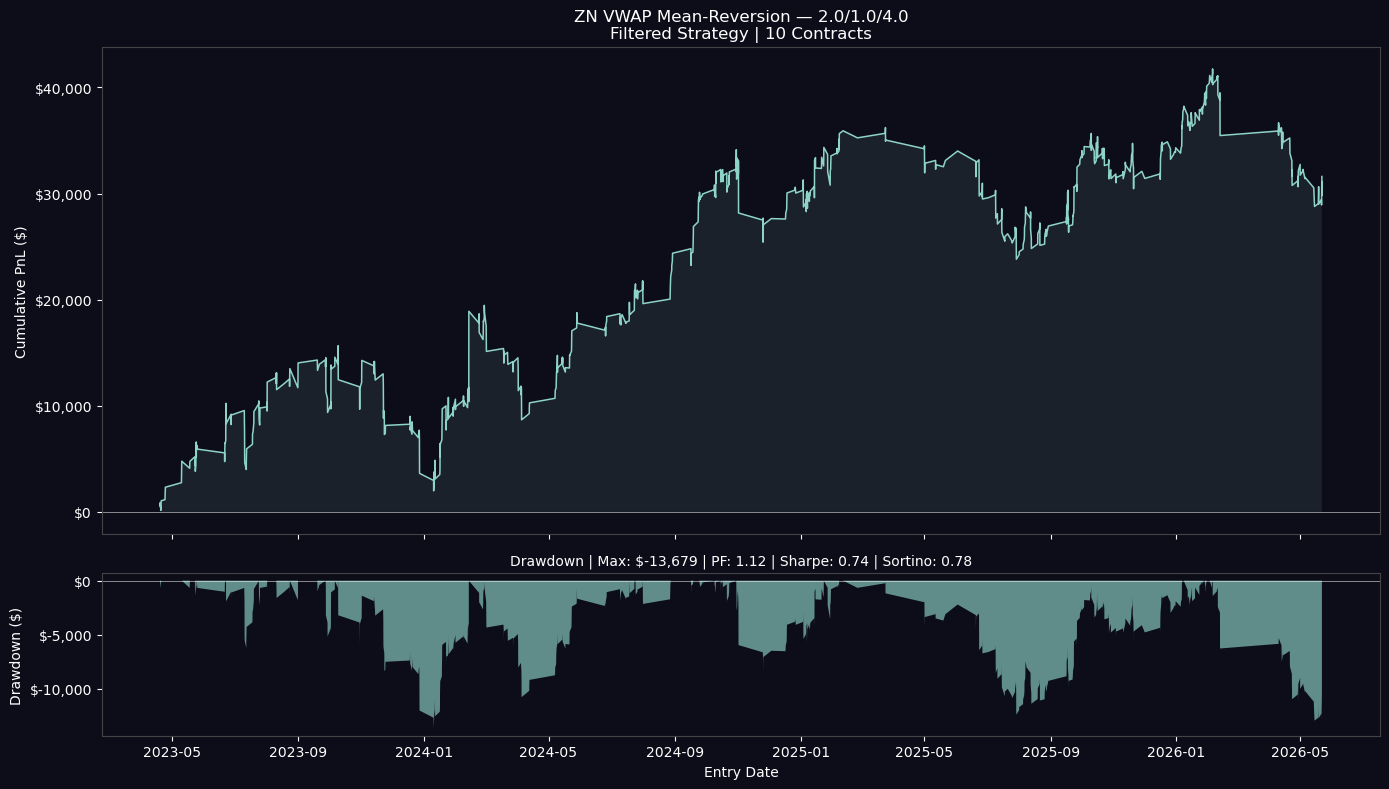

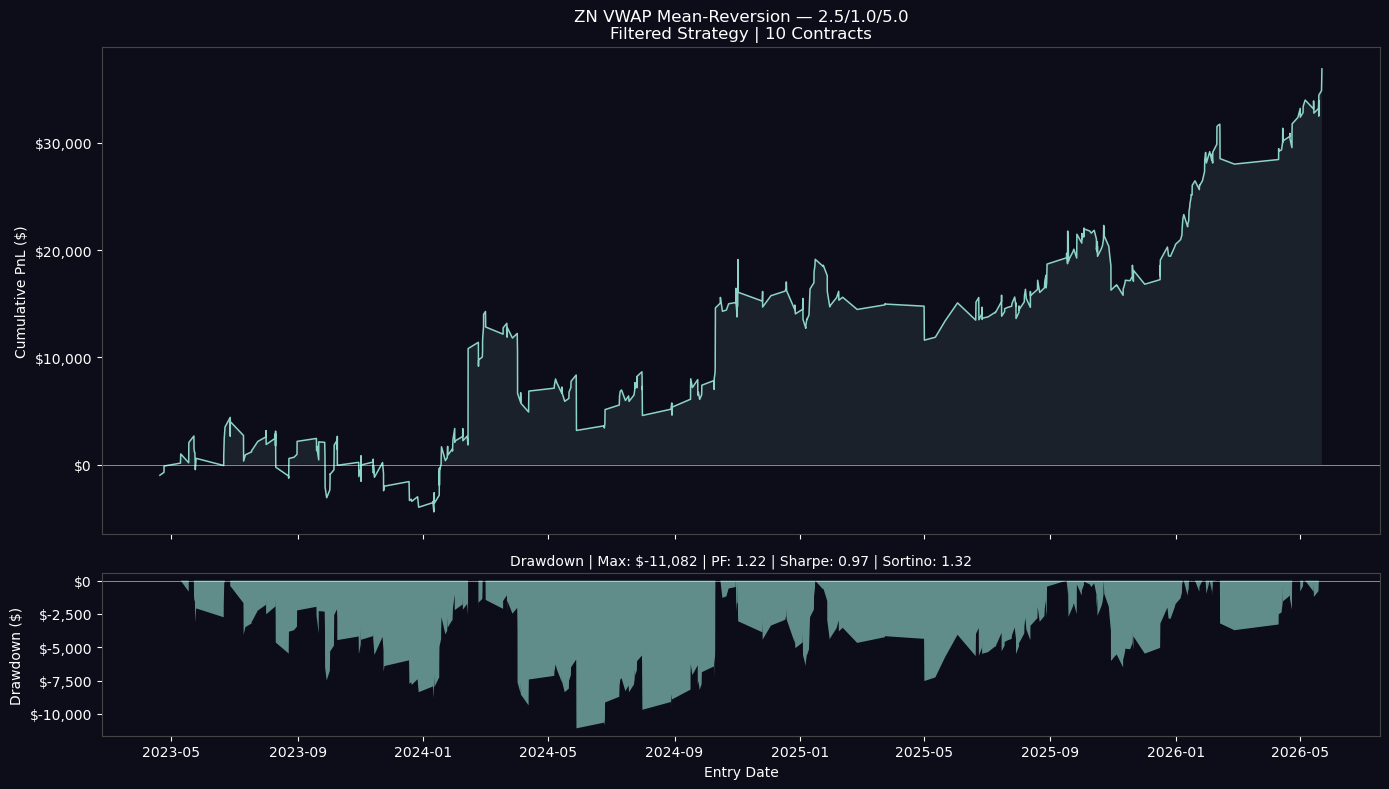

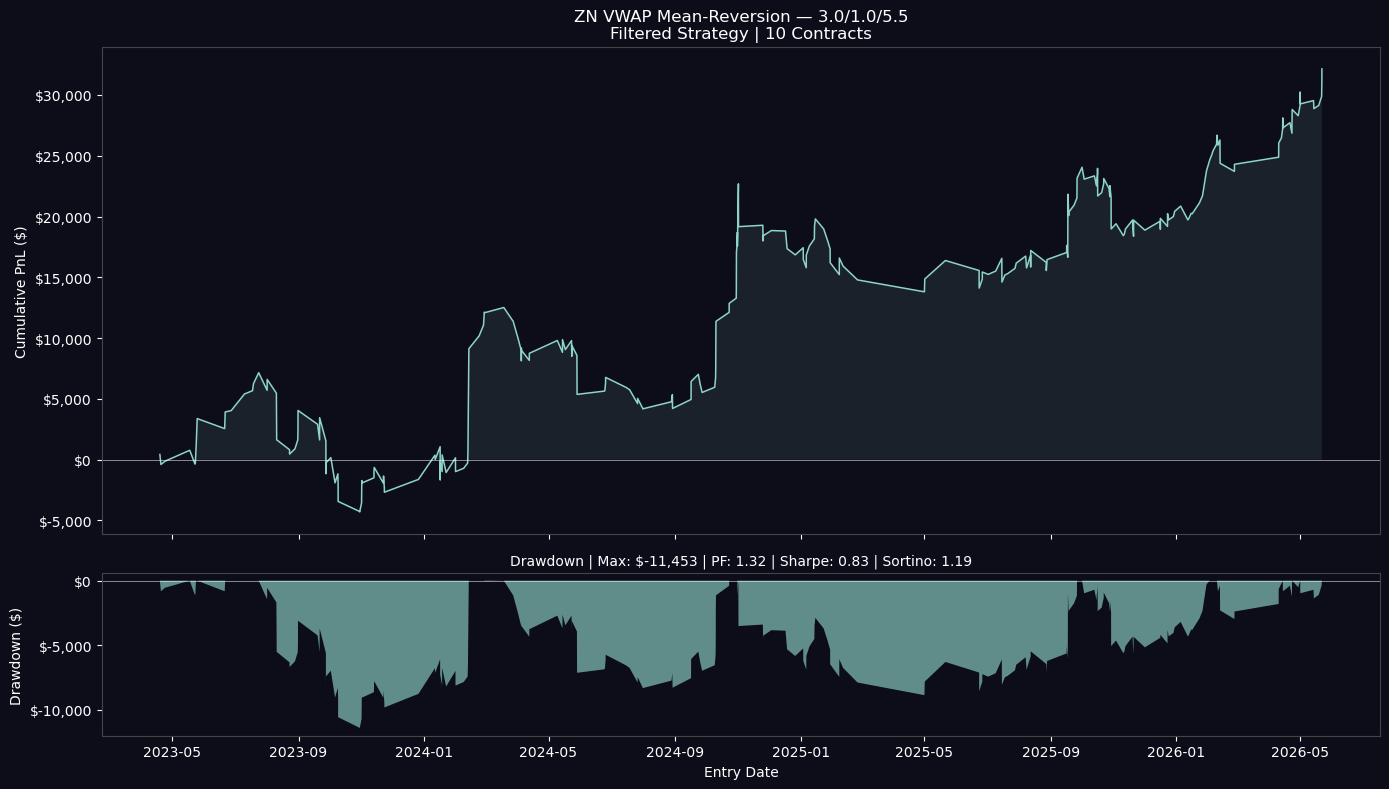

In [40]:
# ── STANDALONE CONFIGURATION COMPARISON + EQUITY CURVES ───────────────────────

standalone_configs = {
    "2.0/1.0/4.0": dict(
        entry_z=2.0,
        exit_z=1.0,
        stop_z=4.0
    ),
    "2.5/1.0/5.0": dict(
        entry_z=2.5,
        exit_z=1.0,
        stop_z=5.0
    ),
    "3.0/1.0/5.5": dict(
        entry_z=3.0,
        exit_z=1.0,
        stop_z=5.5
    ),
}

standalone_rows = []
standalone_trades = {}
standalone_stats = {}

for name, zparams in standalone_configs.items():

    params = dict(
        **zparams,
        tick_size=ZN_TICK_SIZE,
        tick_value=ZN_TICK_VALUE,
        commission=ZN_COMMISSION,
        atr_max=85,
        skip_policy=True,
        vol_max=3.0,
        contracts=10,
        min_warmup=60,
        max_bars_held=480,
        no_entry_hour_et=16,
        no_entry_minute_et=30,
        force_exit_hour_et=16,
        force_exit_minute_et=55
    )

    trades = backtest(
        df_zn,
        **params,
        label=f"ZN FULL {name} filtered"
    )

    trades = (
        trades
        .sort_values("entry_time")
        .reset_index(drop=True)
    )

    trades["entry_time"] = pd.to_datetime(
        trades["entry_time"],
        utc=True
    )

    trades["cum_pnl"] = (
        trades["pnl"].cumsum()
    )

    trades["entry_month"] = (
        trades["entry_time"]
        .dt.tz_localize(None)
        .dt.to_period("M")
    )

    monthly = (
        trades
        .groupby("entry_month")["pnl"]
        .sum()
    )

    monthly_mean = monthly.mean()
    monthly_std = monthly.std(ddof=1)

    sharpe = (
        monthly_mean / monthly_std * np.sqrt(12)
        if monthly_std > 0
        else np.nan
    )

    downside = (
        monthly[monthly < 0]
    )

    downside_dev = (
        np.sqrt(
            np.mean(
                downside.to_numpy() ** 2
            )
        )
        if len(downside) > 0
        else 0.0
    )

    sortino = (
        monthly_mean / downside_dev * np.sqrt(12)
        if downside_dev > 0
        else np.inf
    )

    peak = (
        trades["cum_pnl"]
        .cummax()
    )

    drawdown = (
        trades["cum_pnl"]
        - peak
    )

    max_drawdown = (
        drawdown.min()
    )

    gross_profit = (
        trades.loc[
            trades["pnl"] > 0,
            "pnl"
        ]
        .sum()
    )

    gross_loss = abs(
        trades.loc[
            trades["pnl"] < 0,
            "pnl"
        ]
        .sum()
    )

    profit_factor = (
        gross_profit / gross_loss
        if gross_loss > 0
        else np.inf
    )

    positive_rate = (
        trades["pnl"] > 0
    ).mean()

    expectancy = (
        trades["pnl"].mean()
    )

    total_pnl = (
        trades["pnl"].sum()
    )

    signal_exit_rate = (
        trades["exit_reason"]
        == "live_zscore_exit"
    ).mean()

    stop_rate = (
        trades["exit_reason"]
        == "fixed_stop"
    ).mean()

    forced_rate = (
        trades["outcome"]
        == "forced"
    ).mean()

    standalone_trades[name] = trades

    standalone_stats[name] = {
        "monthly": monthly,
        "drawdown": drawdown,
        "sharpe": sharpe,
        "sortino": sortino,
        "profit_factor": profit_factor,
        "max_drawdown": max_drawdown,
        "positive_rate": positive_rate,
        "signal_exit_rate": signal_exit_rate,
        "stop_rate": stop_rate,
        "forced_rate": forced_rate,
        "expectancy": expectancy,
        "total_pnl": total_pnl,
    }

    standalone_rows.append({
        "Config": name,
        "Trades": len(trades),
        "Positive Rate": positive_rate,
        "Expectancy": expectancy,
        "Total PnL": total_pnl,
        "Max Drawdown": max_drawdown,
        "Profit Factor": profit_factor,
        "Sharpe": sharpe,
        "Sortino": sortino,
    })


# ── COMPARISON TABLE ───────────────────────────────────────────────────────────

standalone_comparison = pd.DataFrame(
    standalone_rows
)

print("\n" + "=" * 100)
print("STANDALONE CONFIGURATION COMPARISON")
print("=" * 100)

display_df = (
    standalone_comparison.copy()
)

display_df["Positive Rate"] = (
    display_df["Positive Rate"]
    .map(lambda x: f"{x:.1%}")
)

display_df["Expectancy"] = (
    display_df["Expectancy"]
    .map(lambda x: f"${x:,.0f}")
)

display_df["Total PnL"] = (
    display_df["Total PnL"]
    .map(lambda x: f"${x:,.0f}")
)

display_df["Max Drawdown"] = (
    display_df["Max Drawdown"]
    .map(lambda x: f"${x:,.0f}")
)

display_df["Profit Factor"] = (
    display_df["Profit Factor"]
    .map(lambda x: f"{x:.2f}")
)

display_df["Sharpe"] = (
    display_df["Sharpe"]
    .map(lambda x: f"{x:.2f}")
)

display_df["Sortino"] = (
    display_df["Sortino"]
    .map(lambda x: f"{x:.2f}")
)

display(
    display_df
    .reset_index(drop=True)
)


# ── EQUITY CURVES + DRAWDOWN PLOTS ────────────────────────────────────────────

for name in standalone_configs.keys():

    trades = standalone_trades[name]
    stats = standalone_stats[name]

    plot_dates = (
        trades["entry_time"]
        .dt.tz_localize(None)
    )

    fig, (ax1, ax2) = plt.subplots(
        2,
        1,
        figsize=(14, 8),
        gridspec_kw={
            "height_ratios": [3, 1]
        },
        sharex=True
    )

    # -------------------------------------------------------------------------
    # EQUITY CURVE
    # -------------------------------------------------------------------------

    ax1.plot(
        plot_dates,
        trades["cum_pnl"],
        linewidth=1.1
    )

    ax1.fill_between(
        plot_dates,
        trades["cum_pnl"],
        0,
        where=(
            trades["cum_pnl"] >= 0
        ),
        alpha=0.10
    )

    ax1.axhline(
        0,
        linewidth=0.6,
        alpha=0.6
    )

    ax1.set_title(
        f"ZN VWAP Mean-Reversion — {name}\n"
        f"Filtered Strategy | 10 Contracts",
        fontsize=12
    )

    ax1.set_ylabel(
        "Cumulative PnL ($)"
    )

    ax1.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda x, _: f"${x:,.0f}"
        )
    )

    # -------------------------------------------------------------------------
    # DRAWDOWN
    # -------------------------------------------------------------------------

    ax2.fill_between(
        plot_dates,
        stats["drawdown"].to_numpy(),
        0,
        alpha=0.65
    )

    ax2.axhline(
        0,
        linewidth=0.6,
        alpha=0.6
    )

    ax2.set_ylabel(
        "Drawdown ($)"
    )

    ax2.set_xlabel(
        "Entry Date"
    )

    ax2.set_title(
        f"Drawdown | "
        f"Max: ${stats['max_drawdown']:,.0f} | "
        f"PF: {stats['profit_factor']:.2f} | "
        f"Sharpe: {stats['sharpe']:.2f} | "
        f"Sortino: {stats['sortino']:.2f}",
        fontsize=10
    )

    ax2.yaxis.set_major_formatter(
        plt.FuncFormatter(
            lambda x, _: f"${x:,.0f}"
        )
    )

    plt.tight_layout()

    filename = (
        "zn_equity_"
        + name.replace(".", "p").replace("/", "_")
        + ".png"
    )

    plt.savefig(
        filename,
        dpi=150,
        bbox_inches="tight"
    )

    plt.show()

## 14. Calendar Spread Extension (Theoretical)

### Framework

Calendar spreads — simultaneously long one delivery month and short another — provide a natural extension of the research because their value is driven by the **relative pricing of adjacent maturities** rather than outright market direction.

In storable commodities, term structure is influenced by financing, storage costs, inventory conditions, convenience yield, and expectations about future supply and demand. These economic relationships provide a more interpretable relative-value anchor than intraday VWAP alone.

Calendar spreads generally carry substantially less outright directional exposure than a naked futures position, although they retain basis, curve, liquidity, and event risk.

### Data Availability

Examination of the raw Databento parent-symbology files confirms the presence of calendar spread instrument data. However, daily trade counts are insufficient for meaningful backtesting:

| Spread | Avg Daily Electronic Trades |
|--------|----------------------------|
| ZNH3-ZNM3 | ~18 |
| 6EM3-6EH3 | ~43 |

Financial futures calendar spreads (ZN, 6E) trade primarily via exchange-for-physical (EFP) and block mechanisms rather than on-screen. Commodity calendar spreads carry substantially greater electronic volume and are a primary risk-management and alpha-generation tool for physical commodity trading desks.

### Applicability

The methodology developed here — AR(1) half-life fitting, event-based reversion analysis, interleaved hold out testing, and Monte Carlo stress testing — transfers directly to commodity calendar spreads where volume is sufficient. The recommended extension path:

1. Obtain CL (WTI crude) or NG (natural gas) spread data
2. Fit AR(1) / OU process to the spread time series directly
3. Apply a stricter expanding walk-forward validation methodology
4. Model basis risk (storage costs, delivery location differentials)

This extension is left for future work given the data availability constraints on the current instruments.

## 15. Conclusions

### ZN 10-Year Treasury Futures

The final analysis provides evidence of an **intraday VWAP-relative mean-reversion effect in ZN that remains profitable under the tested execution assumptions**, although its strength depends materially on parameter choice, market regime, and position-sizing objective.

| Metric | Result |
|--------|--------|
| Intraday AR(1) half-life | 19.2 minutes |
| Intraday AR(1) R² | 0.932 |
| 2.5σ four-hour reversion rate | 80.7% |
| Median time to reversion | 46 minutes |
| Price / VWAP contribution | 54% / 46% |
| Filtered 2.0/1.0/4.0 IS expectancy | $42/trade |
| Filtered 2.0/1.0/4.0 IS positive rate | 67.2% |
| 10-contract MC evaluation pass rate | 55.5% |
| Best MC pass rate by size | 92.9% (3 contracts) |
| Best MC avg net / attempt | $11,669 (5 contracts) |
| Best historical prop replay | $7,989 net (8 contracts) |
| Best standalone configuration | 2.5/1.0/5.0 |
| Best standalone PnL | $36,875 |
| Best standalone Sharpe / Sortino | 0.97 / 1.32 |

**Statistical reversion and trading profitability are distinct.** ZN z-score deviations exhibit strong short-horizon convergence, but the economic value of that convergence depends on entry threshold, stop geometry, transaction costs, and regime selection.

**Regime filters improve trade quality at the cost of frequency.** Across all tested ZN configurations, filtering removes roughly 72–74% of trades while increasing expectancy and improving modeled prop-account pass rates.

**There is no universally optimal parameter or position size.** The 2.0/1.0/4.0 specification performs best for modeled prop-account objectives; 2.5/1.0/5.0 produces the strongest standalone risk-adjusted profile; and 3.0/1.0/5.5 produces the highest standalone expectancy per trade.

**Position sizing dominates prop-account outcomes.** Monte Carlo and historical replay both favor intermediate sizing when survival and net payouts are considered together.

---

### 6E Euro FX Futures

The same framework **does not produce a profitable strategy in 6E**.

| Metric | Result |
|--------|--------|
| Intraday AR(1) half-life | 38.0 min |
| Four-hour reversion rate | 79.0% |
| Filtered IS expectancy | −$16/trade |
| Filtered OOS expectancy | −$58/trade |
| IS profit factor | 0.97 |
| OOS profit factor | 0.89 |

This negative result is informative: 6E exhibits statistical reversion, but its slower decay, lower dollar tick value, and commission burden prevent the tested strategy from producing positive net expectancy.

---

### Data Quality & Research Process

A major methodological finding was the discovery that **parent futures symbology mixed outright contracts with calendar-spread instruments**. When aggregated directly into OHLCV bars, these prices created artificial extreme ranges and distorted early signal calculations. The final dataset filters every raw file to a designated front-month outright contract before one-minute aggregation. Independent comparison with Rithmic historical data helped identify the issue.

The broader lesson: **systematic research is as much a data- and implementation-validation problem as a modeling problem**. Several apparently strong early results changed materially when data handling, signal dispersion, session boundaries, filters, and execution logic were corrected. The final results are weaker than the initial backtests but substantially more defensible.

---

### Limitations

- IS/OOS months are interleaved holdouts rather than a completely untouched final test set
- Monte Carlo draws trades independently and does not reproduce all time dependence in realized returns
- Historical prop-account simulations depend on modeled account rules and should not be interpreted as forecasts of actual income
- Backtests use one-minute bars rather than full order-book simulation
- Slippage beyond modeled commissions is not explicitly estimated
- Parameter selection was informed by repeated research iterations, introducing some degree of research-selection bias

Despite these limitations, the project demonstrates an **end-to-end systematic research process**: raw tick-data validation, feature engineering, signal diagnostics, backtesting, out-of-sample robustness testing, transaction-cost analysis, stochastic stress testing, position-sizing analysis, and cross-market comparison.